<center><span style="font-size:50px;"><b>ANALYSIS OF CUTS ON MC</b></span></center>

In this notebook we want to search for the best cuts of the Monte Carlo data, in order to try them later in real data.

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

---

---

<center><span style="font-size:35px;"><b>UPLOADING DATA</b></span></center>

#### ALL OUR DATA

In [2]:
# %%bash
# ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

#### UPLOAD DATA
Let's upload the data while:
* ignoring useless columns ("neg_pt", "pos_pt")
* substituting (or rather summarizing them) the columns of MC info with a single column telling us who is D0 (1), who anti-D0 (-1) and who background (0)

In [3]:
# directory where the files are stored
folder = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"
all_files = glob.glob(os.path.join(folder, "*.pkl"))
# choose eventually which columns to exclude:
useless_cols = []
# useless_cols = ["neg_pt", "pos_pt"]

# choose how many files to load
x = 47                              # change this to the number of files you want (or your RAM can afford..)
files_to_load = all_files[:x]

print(f"Found {len(all_files)} files. Loading up to {len(files_to_load)} files")

Found 57 files. Loading up to 47 files


In [4]:
# initialization
final_results = pd.DataFrame()

# UPLOAD ---------------------------------------------------------------------
for i, f in enumerate(files_to_load, start=1):
    
    # UPLOAD DATA excluding useless columns:
    df = pd.read_pickle(f)
    df = df.drop(columns=useless_cols)

    # DEFINING MASKS to decrease the number of columns by summarizing them:
    mask_true_d0 = (
        (df["track_pdg_pos"] == 211 ) &
        (df["track_pdg_neg"] == -321 ) &
        (df["mother_pdg_pos"] == 421) &
        (df["mother_pdg_neg"] == 421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_true_anti_d0 = (
        (df["track_pdg_pos"] == 321) &
        (df["track_pdg_neg"] == -211) &
        (df["mother_pdg_pos"] == -421) &
        (df["mother_pdg_neg"] == -421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_background = ( (~mask_true_d0) & (~mask_true_anti_d0) )

    # SUMMARIZE some columns:
    df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0] , [1, -1], default=0)
    summarized_cols = ["track_pdg_pos", "track_pdg_neg", "mother_pdg_pos", "mother_pdg_neg", "beauty_pdg_pos", "beauty_pdg_neg",
                     "mother_N_final_state_pos", "mother_N_final_state_neg", "mother_orig_ind_pos", "mother_orig_ind_neg"]
    df = df.drop(columns=summarized_cols)

    # FINAL single file uploaded:
    final_results = pd.concat([final_results, df], ignore_index=True)
    
    # free memory
    del df
    gc.collect()
    
    # debug
    print(f"{i}", end=' ')

print(f"\nFinished: loaded {i} files out of {len(all_files)} available.")

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 
Finished: loaded 47 files out of 57 available.


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 40_889_301 rows and 19 columns.
It occupies 5_927.25 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,pos_pt,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,truth
0,-1.306505e-03,1.647857,1.449501,1.590537,2.064567,0.378364,0.443343,-6.947757,133.719315,-0.093189,1.610355,-1.825205,6352.559082,0.014020,0.260088,951.748230,-0.417602,587.019836,0
1,-7.080836e-03,0.947897,0.935076,0.698830,5.386100,-0.238735,0.443343,-6.947757,133.719315,-0.093189,0.493763,-0.913118,-1072.173340,0.075984,0.260088,951.748230,-6.905696,-147.886261,0
2,5.584245e-03,0.813485,0.819674,0.772823,3.091237,0.265503,0.443343,-6.947757,133.719315,-0.093189,0.334891,1.178568,-999.000000,-0.059924,0.260088,951.748230,-6.446581,-999.000000,0
3,-1.640872e-02,0.966982,0.953821,0.597828,3.955609,-0.544734,0.443343,-6.947757,133.719315,-0.093189,0.436598,69.200188,-999.000000,0.176080,0.260088,951.748230,24.368649,-999.000000,0
4,1.596988e-02,1.400717,1.328300,0.452560,3.330226,0.408916,0.443343,-6.947757,133.719315,-0.093189,0.725583,-0.713104,-999.000000,-0.171371,0.260088,951.748230,-2.782018,-999.000000,0
40889296,-1.763569e-05,3.198169,3.246417,1.482737,0.005441,-0.653144,2.368999,1.026240,-999.000000,-0.003540,1.076981,-1.107388,22.093863,0.004982,-1.161817,-999.000000,-0.262186,6.665131,0
40889297,-1.574277e-05,1.284093,1.105303,1.480479,0.023373,-0.967789,0.422424,-7.260705,-999.000000,-0.003160,1.076981,-1.107388,22.093863,0.004982,-0.489060,-999.000000,-0.262186,6.665131,0
40889298,-3.896312e-05,1.617500,1.802457,1.419381,0.010298,0.895121,1.385533,1.385523,25.581936,-0.004089,0.346672,1.784249,-999.000000,0.009529,-0.543696,37.019440,-7.573249,-999.000000,0
40889299,-4.874647e-05,1.048626,1.159036,0.644173,0.009725,-0.711689,0.698784,1.271455,2.422411,-0.005116,0.346672,1.784249,-999.000000,0.009529,3.275607,35.436344,-7.573249,-999.000000,0
40889300,8.066739e-07,1.794777,1.815179,0.770033,0.001932,-0.325767,0.762130,-1.394995,-20.621355,0.000592,0.627887,-0.887615,-0.675870,0.001363,-0.912751,-0.895590,-2.794795,-26.152786,0


---

## TRUE $D_0$ IN OUR DATA

In [6]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

In [7]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       7463
Number of anti-D0:  7785
Number of background pairs: 40_874_053
Fraction of D0 and anti-D0 over total: 0.0373%


The variables we have to work with are:

In [8]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_pt', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY',
       'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi',
       'neg_TOFpi', 'pos_TPCka', 'pos_TOFka', 'truth'],
      dtype='object')


Example: the variable 'neg_TOFka' refers to the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which is a $K^-$ for the $D^0$ case, a $\pi^-$ for the $anti-D^0$ case, and something else in background case.

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS PLOT</b></span></center>

We now plot the data, remembering to plot both the columns for mass and anti-mass because we want to include the reflex component.

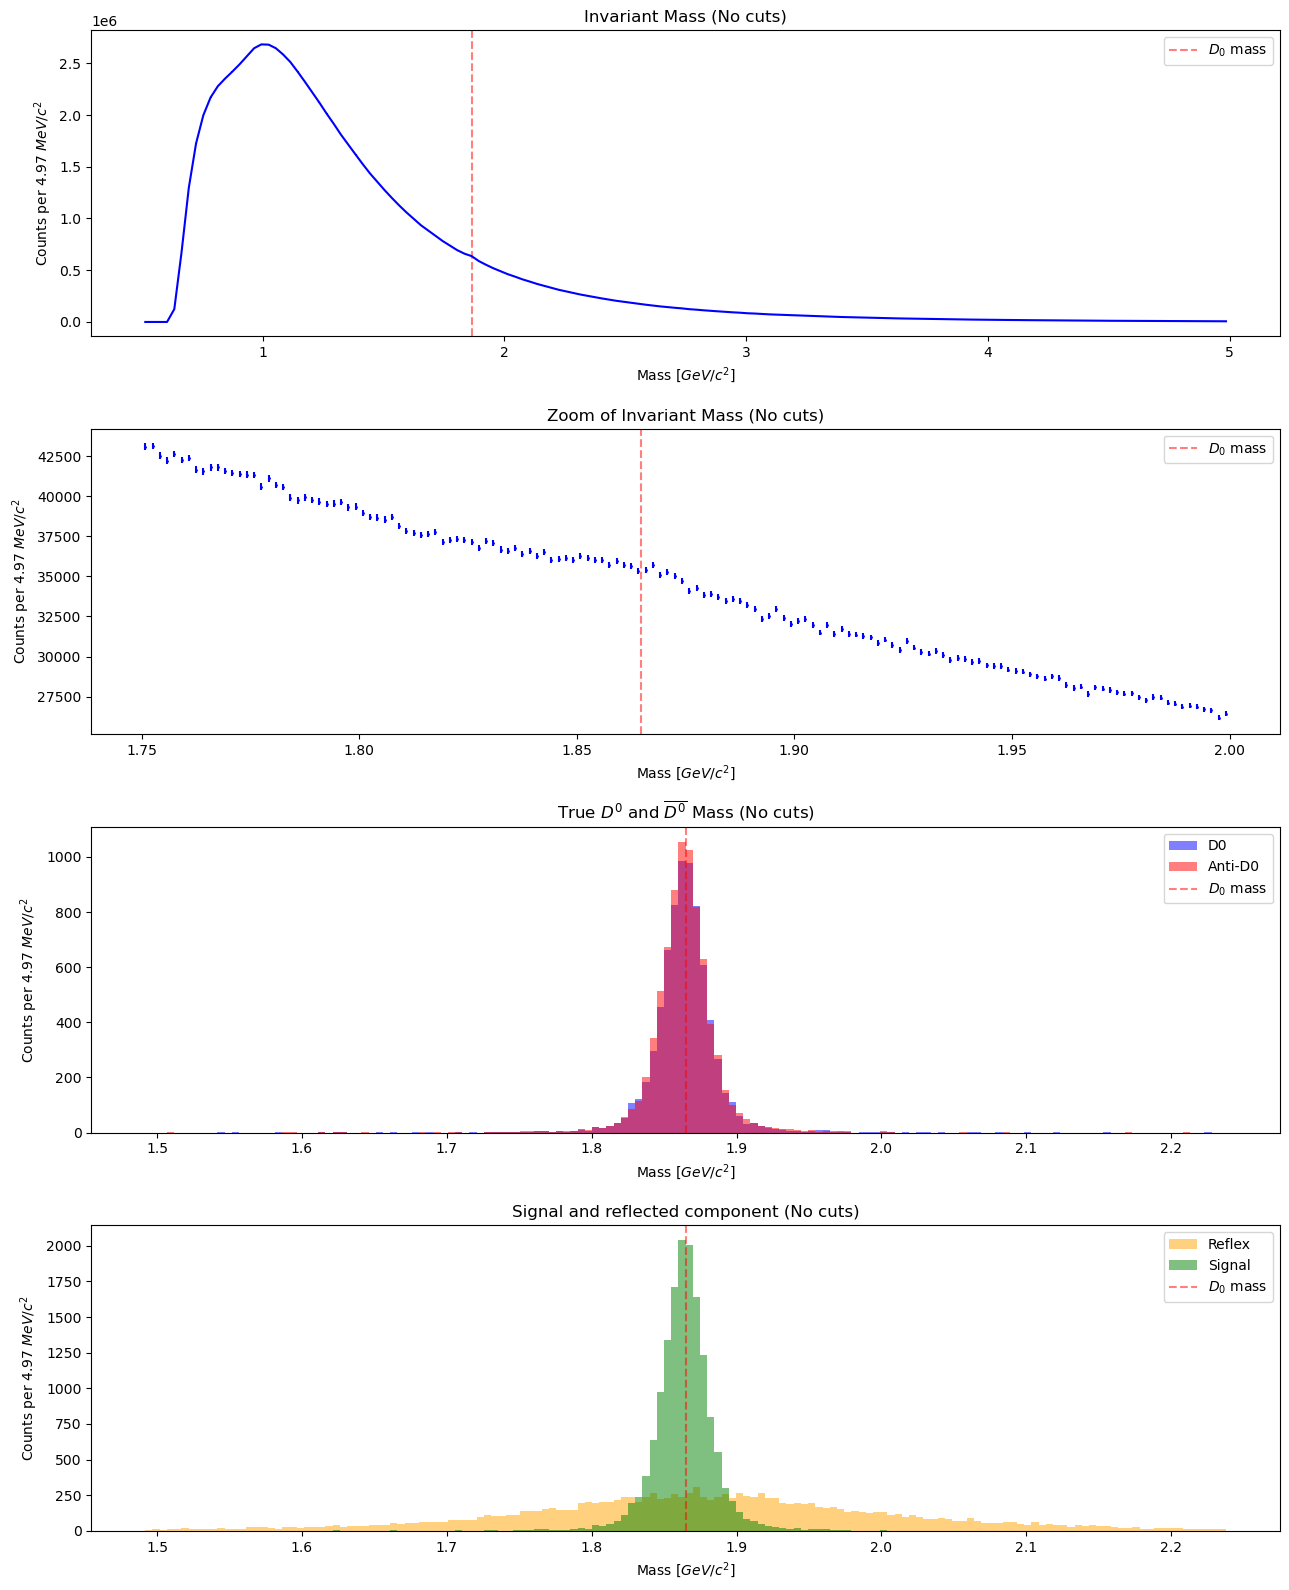

In [9]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 150

num_of_plots = 4
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,4*num_of_plots)  )

# GLOBAL PLOT ---------------------------------------- 
data = np.concatenate([final_results["inv_mass"].values, final_results["anti_mass"].values])
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(0.5, 5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs[0].errorbar(bin_centers, counts, yerr=errors, fmt='-', markersize=2, color='blue')
axs[0].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No cuts)")
axs[0].legend()


# ZOOM OF GLOBAL PLOT ---------------------------------------- 
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(1.75, 2))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)
axs[1].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("Zoom of Invariant Mass (No cuts)")
axs[1].legend()

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO ---------------------------------------- 
data = final_results.loc[mask_true_d0, "inv_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = final_results.loc[mask_true_anti_d0, "anti_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title(r"True $D^0$ and $\overline{{D^0}}$ Mass (No cuts)")
axs[2].legend()
#axs[2].set_xticks( np.arange(1.6, 2.2, 0.05) )

#  ---------------------------------------- 
# PLOTTING signal (D0 mass + anti-D0 anti-mass) reflex component (D0 anti-mass + anti-D0 mass)
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
axs[3].hist( reflex_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="orange", alpha=0.5, label="Reflex")
axs[3].hist( signal_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="green", alpha=0.5, label="Signal")
axs[3].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[3].set_xlabel("Mass [$GeV/c^2$]")
axs[3].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[3].set_title(r"Signal and reflected component (No cuts)")
axs[3].legend()



del data
#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.  

Also the distribution of $D_0$ and $anti-D_0$ is almost the same.

---

---

---

<center><span style="font-size:35px;"><b>TRACK VARIABLES DISTRIBUTION</b></span></center>

Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $p_T$ OF SINGLE TRACKS

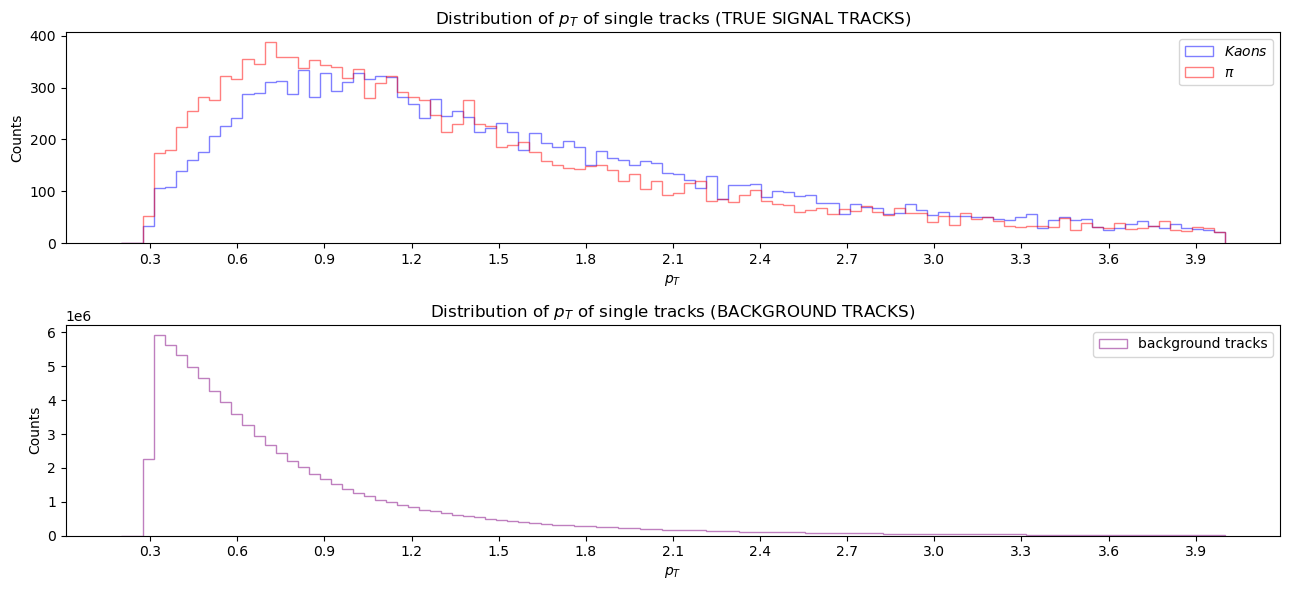

In [32]:
N_BINS = 100
range_min = 0.2
range_max = 4

num_of_plots = 2
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,3*num_of_plots)  )

# TRUE SIGNAL ---------------------------------------- 
data = np.concatenate( [ final_results.loc[ mask_true_d0, "neg_pt"].values, final_results.loc[ mask_true_anti_d0, "pos_pt"].values] )
axs[0].hist( data , bins=N_BINS, range=(range_min, range_max), color="blue", alpha=0.5, label=r"$Kaons$", histtype='step')
data = np.concatenate( [ final_results.loc[ mask_true_d0, "pos_pt"].values, final_results.loc[ mask_true_anti_d0, "neg_pt"].values] )
axs[0].hist( data , bins=N_BINS, range=(range_min, range_max), color="red",  alpha=0.5, label=r"$\pi$", histtype='step')
axs[0].set_xlabel(r"$p_T$")
axs[0].set_ylabel("Counts")
axs[0].set_title(r"Distribution of $p_T$ of single tracks (TRUE SIGNAL TRACKS)")
axs[0].set_xticks(np.arange(0.3, range_max, 0.3))
axs[0].legend()

# BACKGROUND ---------------------------------------- 
data = np.concatenate( [final_results.loc[mask_background, "neg_pt"].values, final_results.loc[mask_background, "pos_pt"].values ] )
axs[1].hist( data , bins=N_BINS, range=(range_min, range_max), color="purple", alpha=0.5, label="background tracks", histtype='step')
axs[1].set_xlabel(r"$p_T$")
axs[1].set_ylabel("Counts")
axs[1].set_title(r"Distribution of $p_T$ of single tracks (BACKGROUND TRACKS)")
axs[1].set_xticks(np.arange(0.3, range_max, 0.3))
axs[1].legend()

plt.tight_layout()
plt.show()

del data

### $\pi^+$ TRACKS
Let's observe the distribution of the variables for the $\pi^+$ tracks, for both the known $D_0$ and also for all the combinatory background.

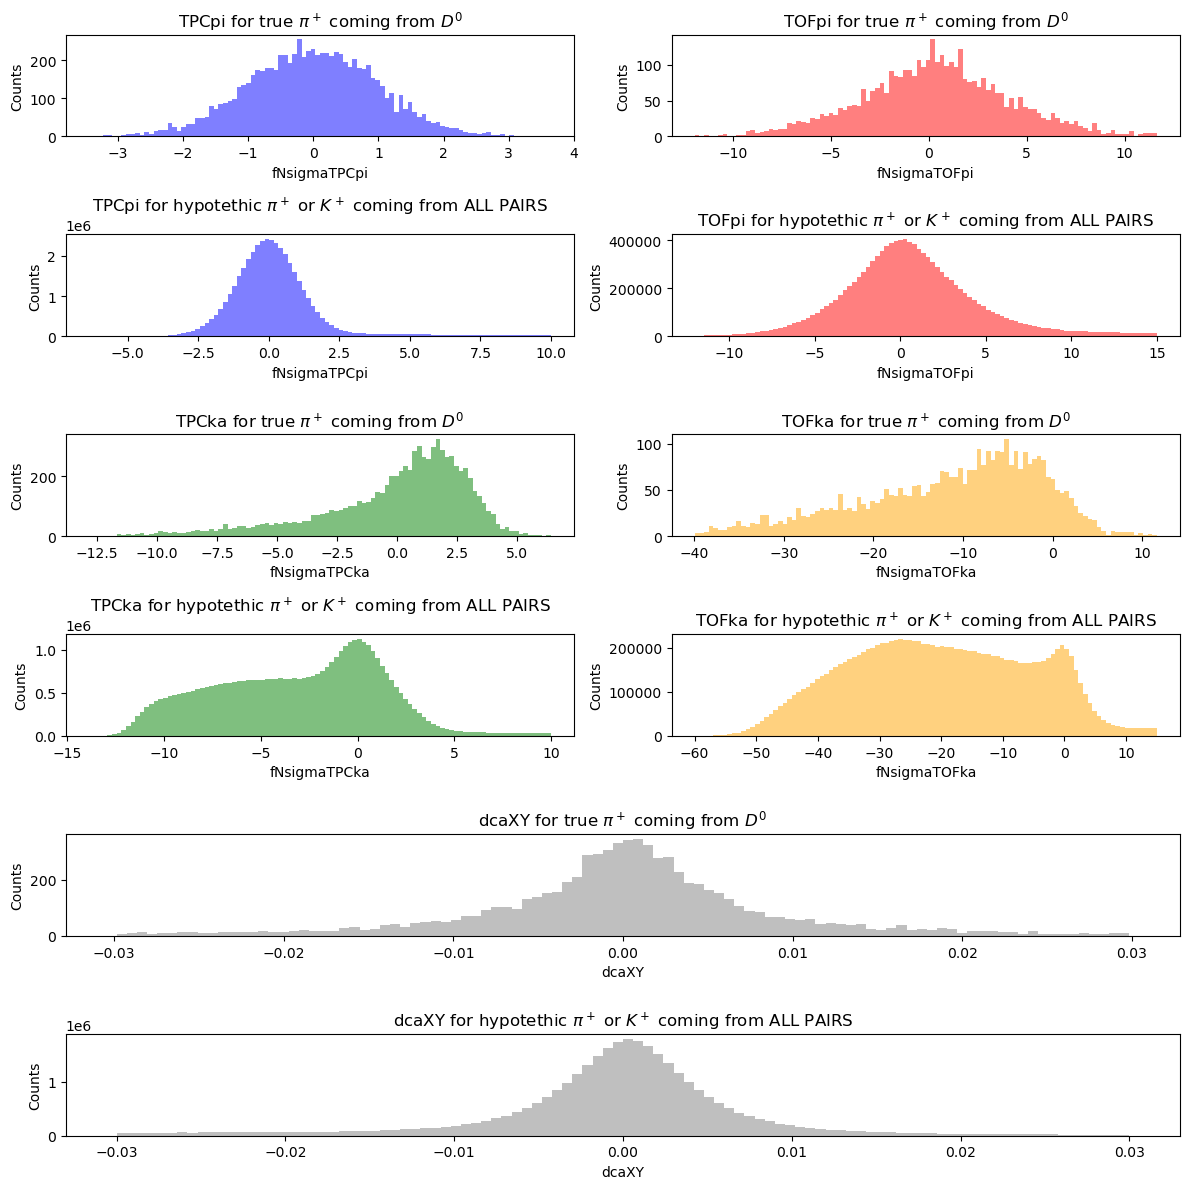

In [11]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_D0", "tofpi_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_D0", "tofka_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12)
)

# --- Plot TPCpi for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for true $\pi^+$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $\pi^+$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['pos_TPCpi'].values
data = data[(data > -7) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['pos_TOFpi'].values
data = data[(data > -12) & (data < 15)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot TPCka for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for true $\pi^+$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TOFka'].values
data = data[(data > -40) & (data < 12)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $\pi^+$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS ---
data = final_results['pos_TPCka'].values
data = data[(data > -20) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['pos_TOFka'].values
data = data[(data > -60) & (data < 15)]
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot dcaXY for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="grey", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for true $\pi^+$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="grey", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $\pi^-$ TRACKS
Let's observe the distribution of the variables for the $\pi^-$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

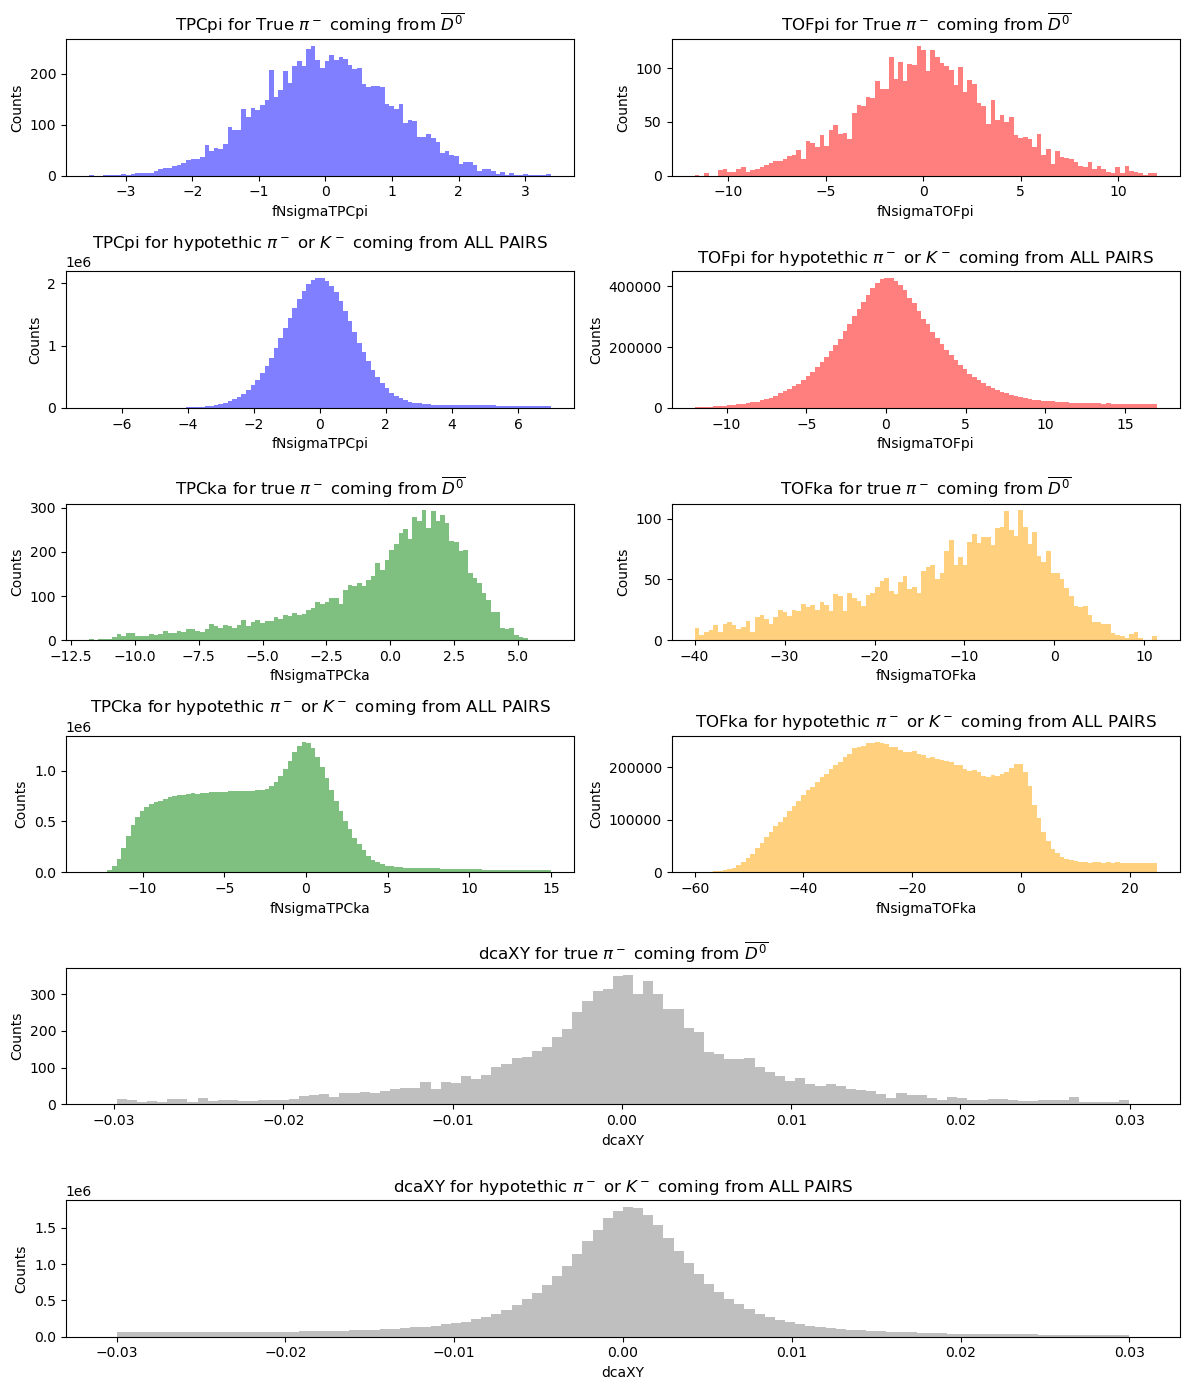

In [12]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_anti_D0", "tofpi_anti_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_anti_D0", "tofka_anti_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 14)
)

# --- Plot TPCpi for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TPCpi'].values
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for True $\pi^-$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for True $\pi^-$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['neg_TPCpi'].values
data = data[(data > -7) & (data < 7)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['neg_TOFpi'].values
data = data[(data > -12) & (data < 17)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TPCka for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for true $\pi^-$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TOFka'].values
data = data[(data > -40) & (data < 12)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $\pi^-$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS ---
data = final_results['neg_TPCka'].values
data = data[(data > -20) & (data < 15)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['neg_TOFka'].values
data = data[(data > -60) & (data < 25)]
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")


# --- Plot dcaXY for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $\pi^-$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $K^-$ TRACKS
Let's observe the distribution of the variables for the $Kaons^-$ tracks, for both the known $D_0$ and also for all the combinatory background.

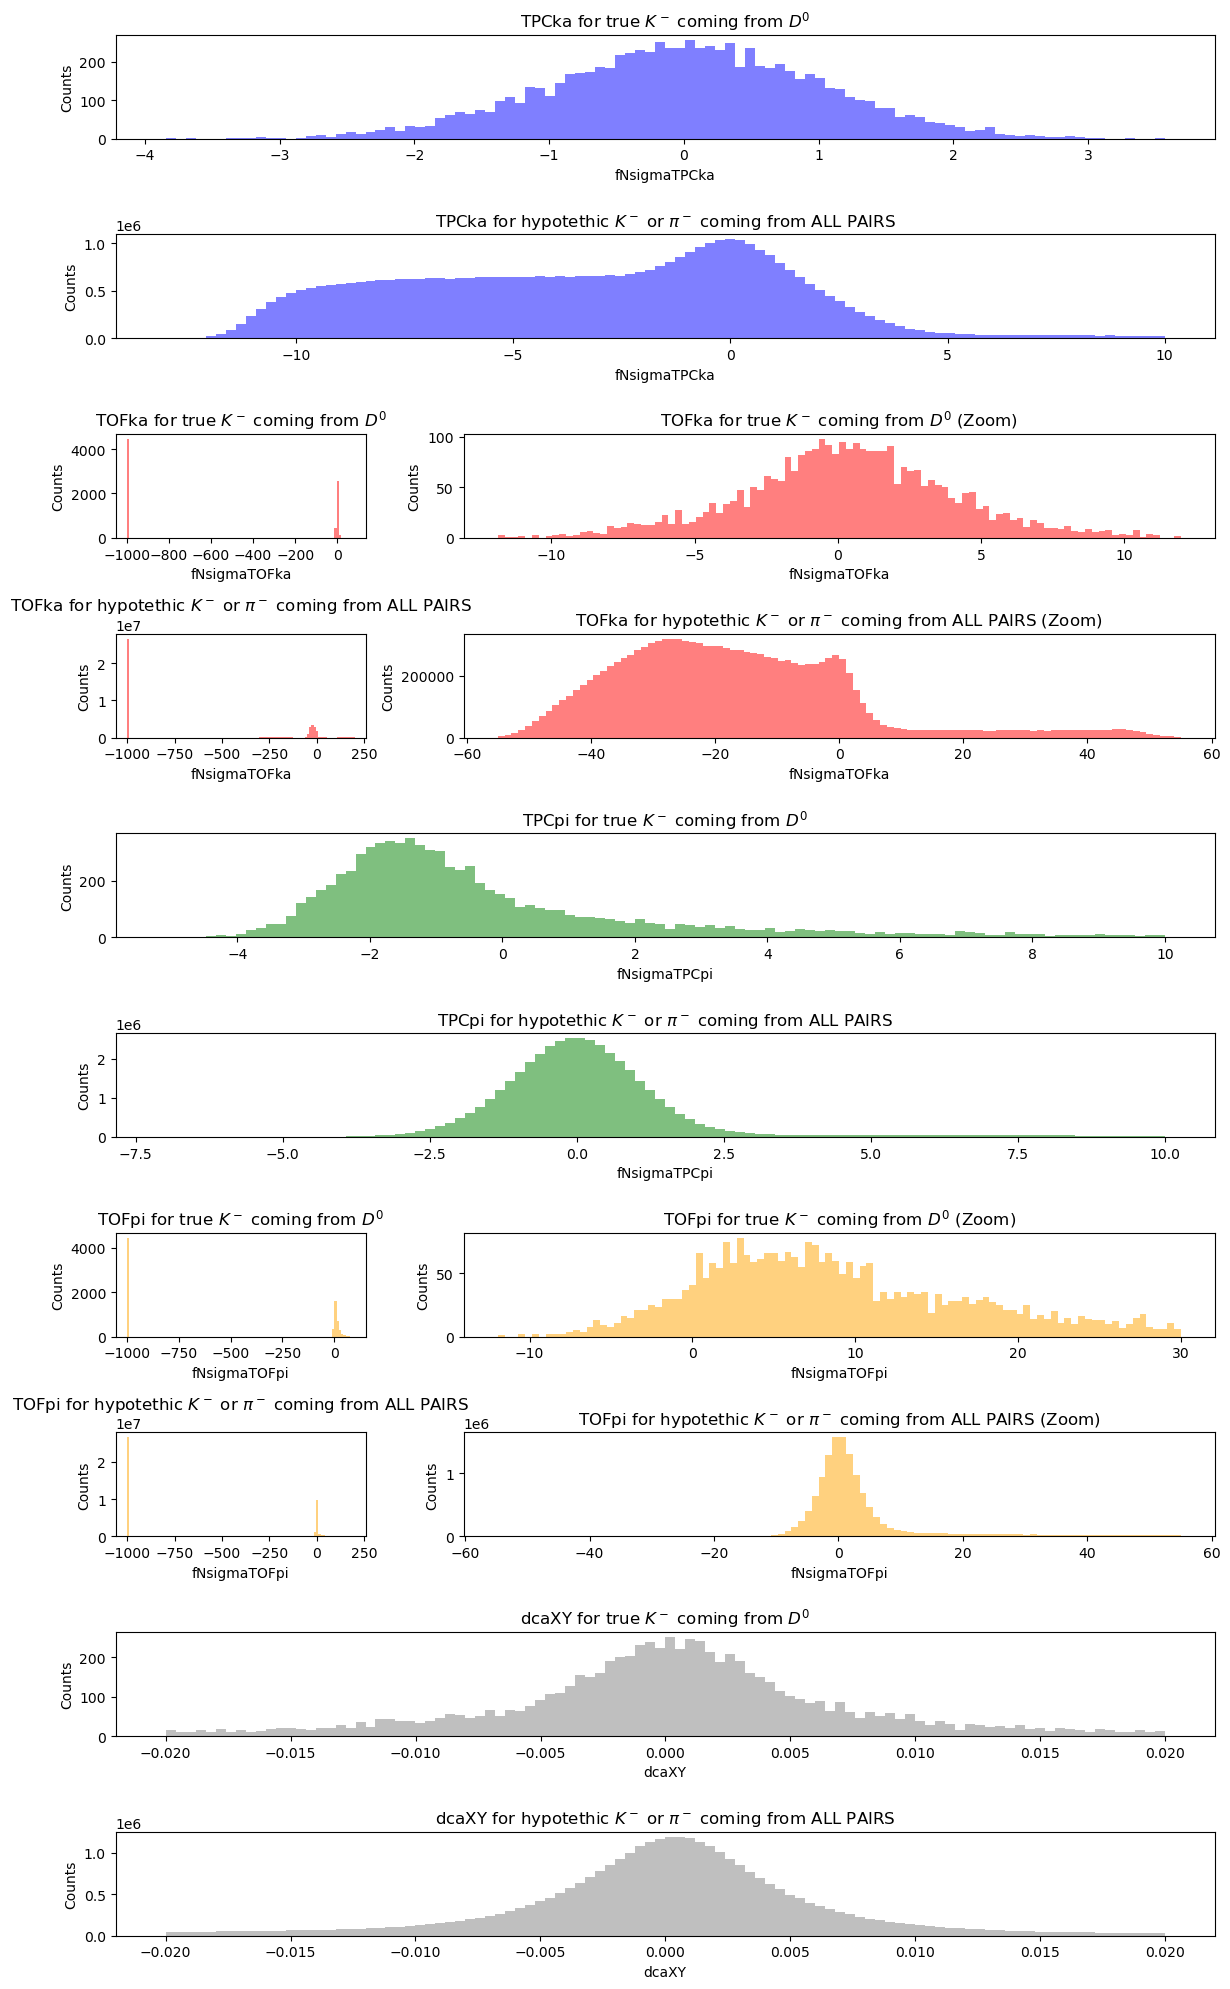

In [13]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_D0", "tpcka_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_D0", "tofka_zoom_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_D0", "tpcpi_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_D0", "tofpi_zoom_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE D0---
data = final_results.loc[mask_true_d0, 'neg_TPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for true $K^-$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['neg_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofka_zoom_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['neg_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot TPCpi FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TPCpi'].values
data = data[ data < 10 ]
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for true $K^-$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS ---
data = final_results['neg_TPCpi'].values
data = data[(data > -13) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 30)]
axes["tofpi_zoom_D0"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofpi_zoom_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR ALL PAIRS ---
data = final_results['neg_TOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofpi_zoom_all"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_all"].set_title(r"TOFpi for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")
#-------------------------------------------------------------------

# --- Plot dcaXY FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for true $K^-$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

### $K^+$ TRACKS
Let's observe the distribution of the variables for the $Kaons^+$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

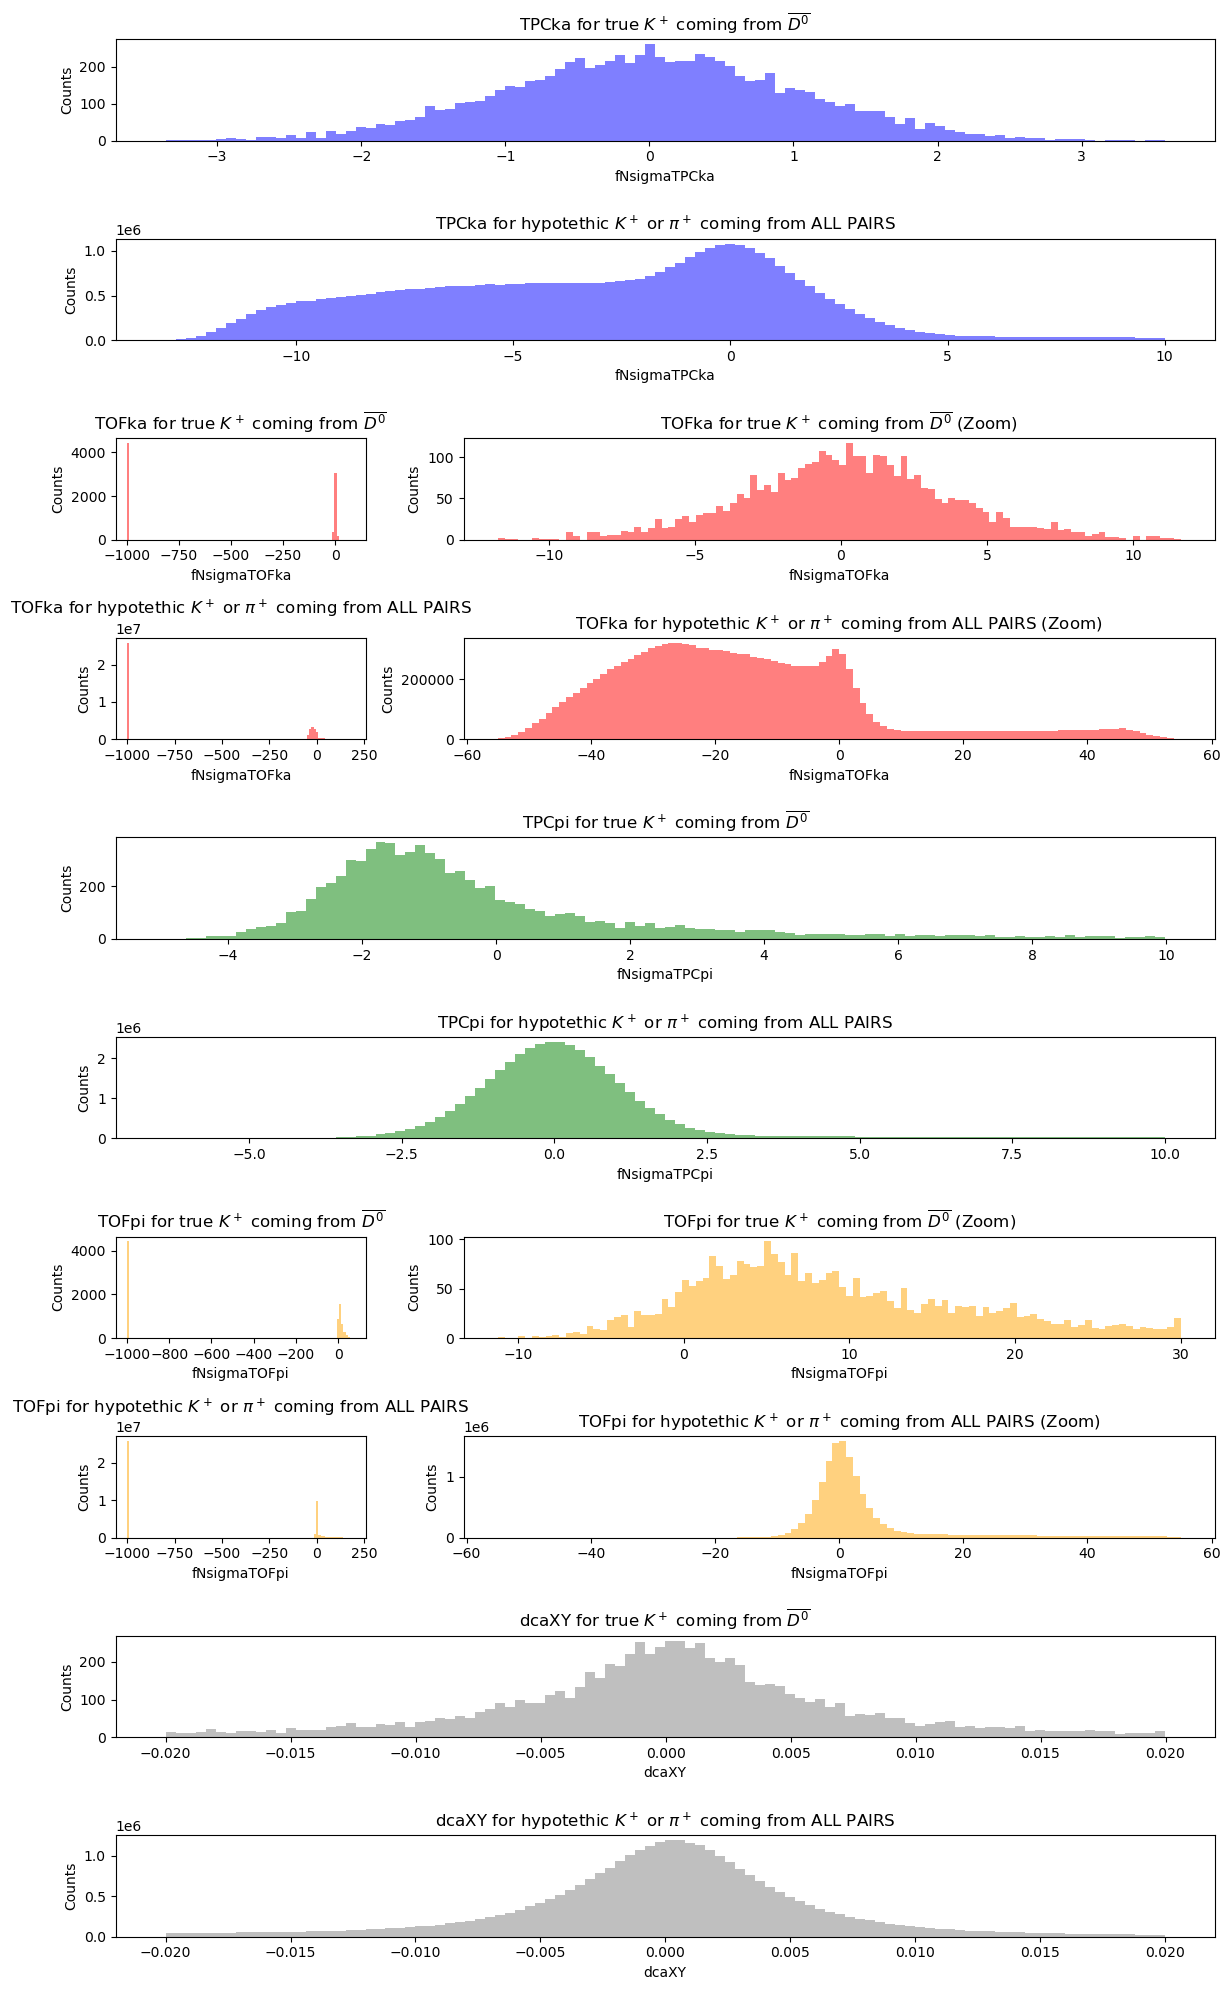

In [14]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_anti_D0", "tpcka_anti_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_anti_D0", "tofka_zoom_anti_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_anti_D0", "tpcpi_anti_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_anti_D0", "tofpi_zoom_anti_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE anti_D0---
data = final_results.loc[mask_true_anti_d0, 'pos_TPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for true $K^+$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['pos_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofka_zoom_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['pos_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")
#-------------------------------------------------------------------

# --- Plot TPCpi FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TPCpi'].values
data = data[ data < 10 ]
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for true $K^+$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS ---
data = final_results['pos_TPCpi'].values
data = data[(data > -13) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 30)]
axes["tofpi_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofpi_zoom_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR ALL PAIRS ---
data = final_results['pos_TOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofpi_zoom_all"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_all"].set_title(r"TOFpi for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot dcaXY FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $K^+$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

We can see that the variables TPCka and TOFka can be very useful as cuts. 

But what to do with data at -999 TOF? Let's see.

In [15]:
print(f"Total number of D0s: {d0_tot}")
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True D0s with TOFka = -999:       {len(data)/d0_tot:.2f}")
print(f"Fraction of True D0s with TOFka != -999: :    { (d0_tot-len(data)) / d0_tot :.2f} \n")

print(f"Total number of antiD0s: {anti_d0_tot}")
data = final_results.loc[mask_true_anti_d0, 'neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True anti_D0s with TOFka = -999:  {len(data)/anti_d0_tot:.2f}")
print(f"Fraction of True anti_D0s with TOFka != -999: { (anti_d0_tot-len(data)) / anti_d0_tot :.2f} \n")

print(f"Total number of data: {len(final_results)}")
data = final_results['neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of all data with TOFka = -999:  :    {len(data)/len(final_results) :.2f}")
print(f"Fraction of all data with TOFka != -999: :    { (len(final_results)-len(data)) / len(final_results) :.2f}")
del data

Total number of D0s: 8007
Fraction of True D0s with TOFka = -999:       0.56
Fraction of True D0s with TOFka != -999: :    0.44 

Total number of antiD0s: 8396
Fraction of True anti_D0s with TOFka = -999:  0.47
Fraction of True anti_D0s with TOFka != -999: 0.53 

Total number of data: 43421134
Fraction of all data with TOFka = -999:  :    0.61
Fraction of all data with TOFka != -999: :    0.39


This is the thing: as we saw in the plots, TOF is the better chance we have at identifying the $D_0$. And if we keep the data with TOFka=-999, we keep a lot of background. In particulare we keep a lot of back ground and some signal difficult to identify (cause we can't use TOF).   
Instead if we remove it, yeah we lose 44% of true D0, but we stay in a zone where our cuts are very effective (see plot above). So cutting away TOFka=-999 could be a good choice.

### FOCUS ON $dca_{XY}$ per $p_T$ of the single tracks
Let's focus on the distribution of $dca_{XY}$ variable in various $p_T$ distributions.

In [16]:
multiple_masks_pt_single_neg_track = [ 
    ( final_results["neg_pt"].between(0,1) ), 
    ( final_results["neg_pt"].between(1,2) ), 
    ( final_results["neg_pt"].between(2,3) ),
    ( final_results["neg_pt"].between(3,4) ), 
    ( final_results["neg_pt"].between(4,5) ), 
    ( final_results["neg_pt"].between(5,6) ) ]
multiple_masks_pt_single_pos_track = [ 
    ( final_results["pos_pt"].between(0,1) ), 
    ( final_results["pos_pt"].between(1,2) ), 
    ( final_results["pos_pt"].between(2,3) ),
    ( final_results["pos_pt"].between(3,4) ), 
    ( final_results["pos_pt"].between(4,5) ), 
    ( final_results["pos_pt"].between(5,6) ) ]
pt_windows_single_track = [ "0-1", "1-2", "2-3", "3-4", "4-5", "5-6"]

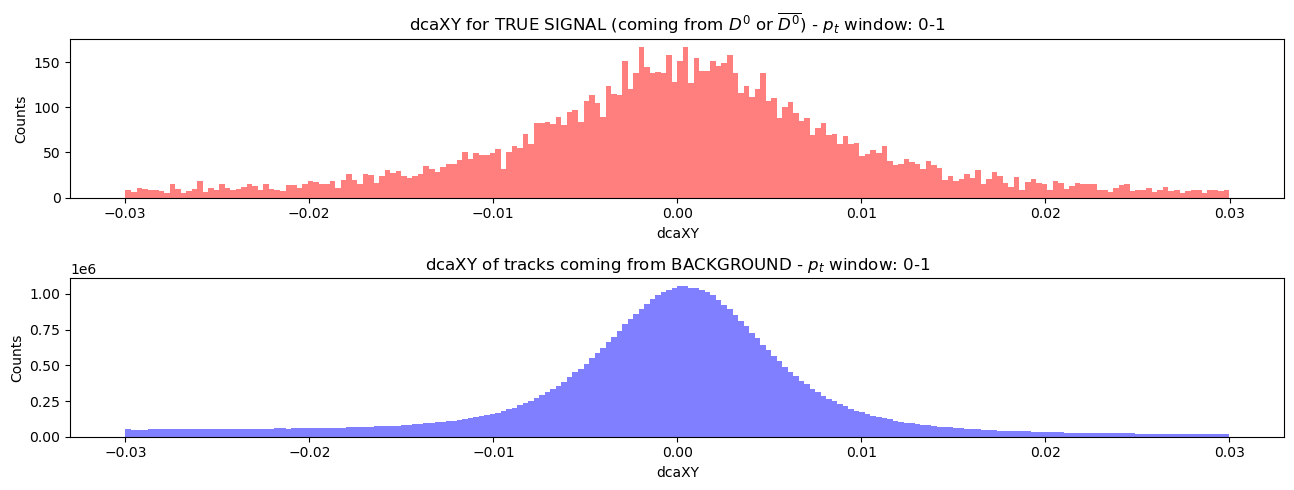

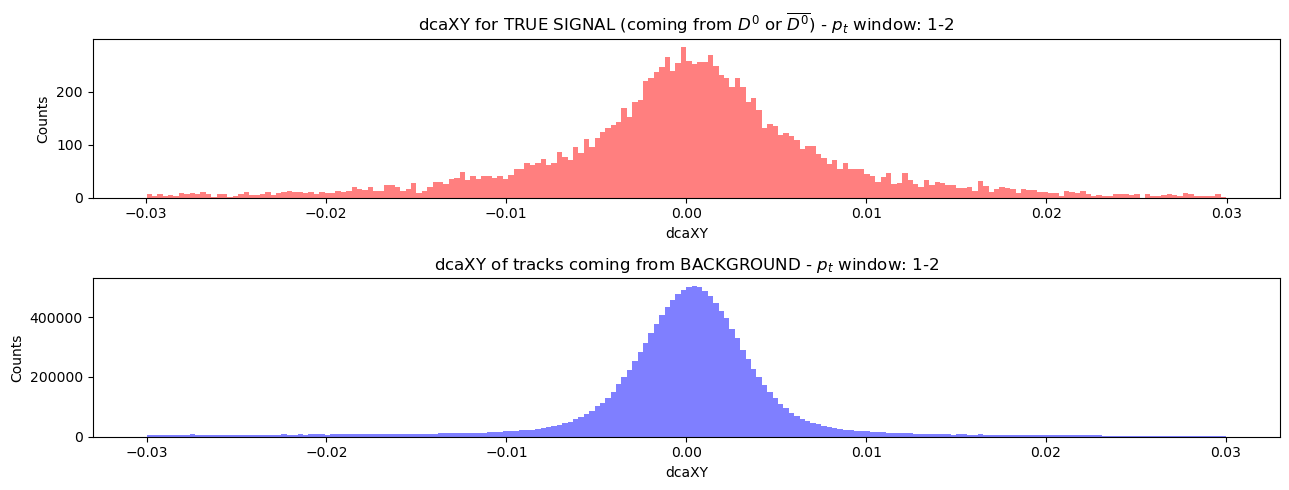

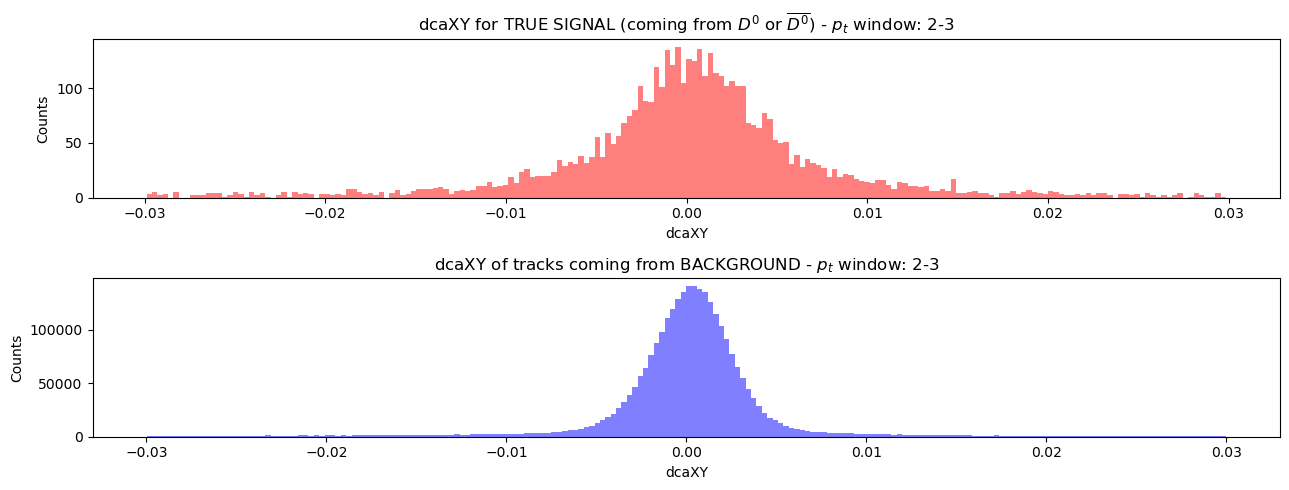

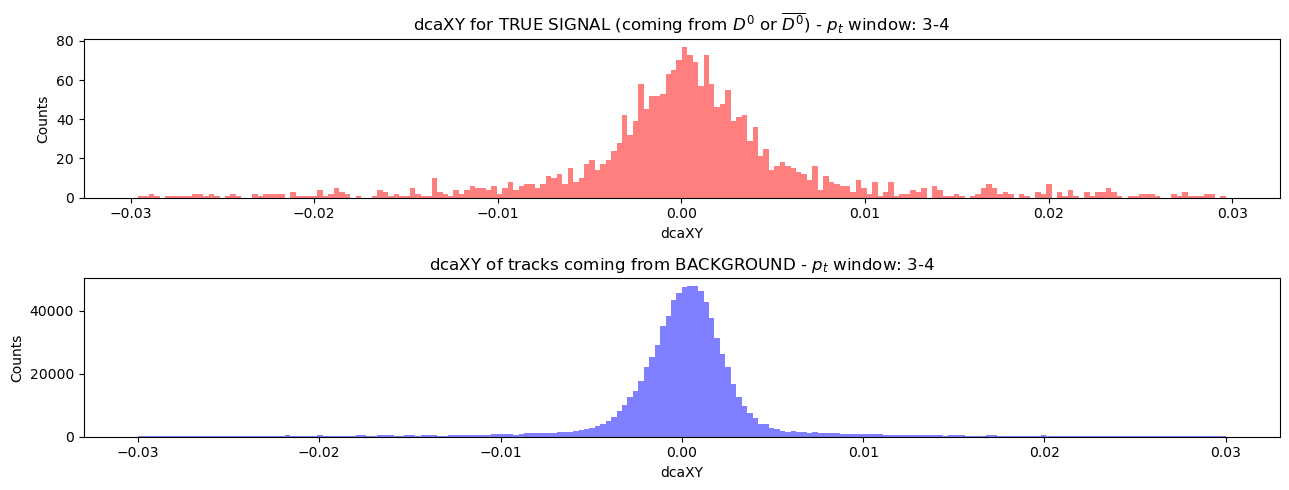

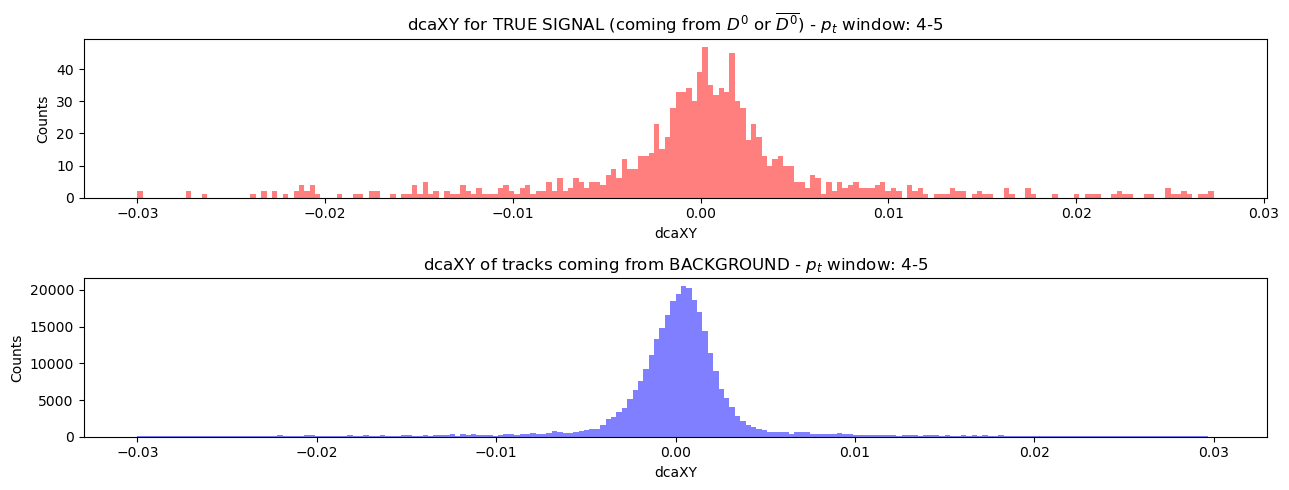

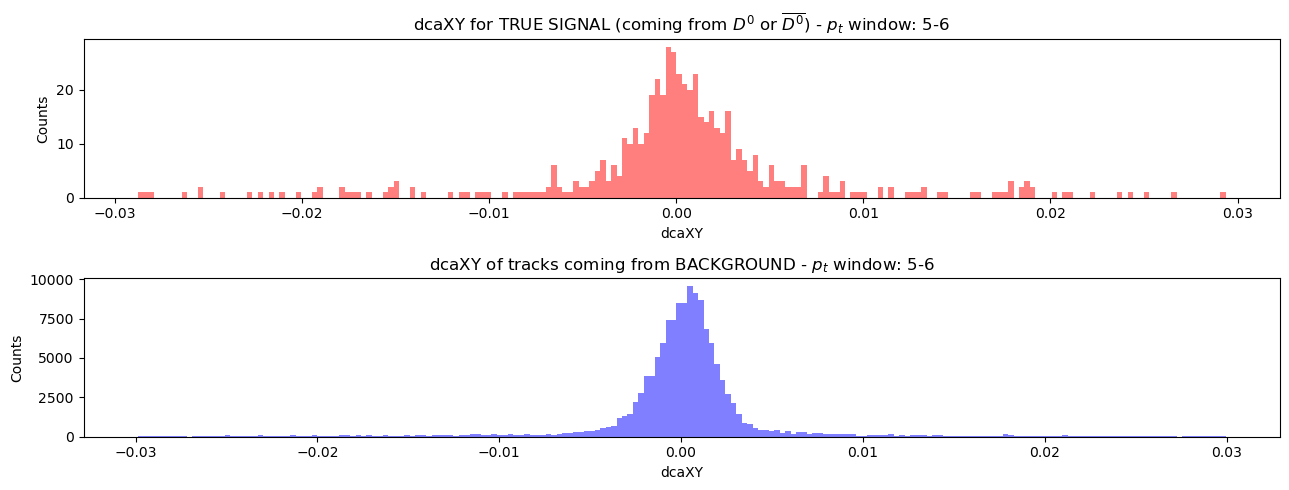

In [17]:
N_BINS = 200

for i, mask_name in enumerate(pt_windows_single_track):
    num_of_plots = 2
    fig, axs = plt.subplots(num_of_plots, 1, figsize=(13, 2.5 * num_of_plots))
    
    #-------------------------------------------------------------------
    # --- Plot dcaXY for TRUE SIGNAL ---
    data = np.concatenate([ final_results.loc[mask_signal & multiple_masks_pt_single_pos_track[i], 'pos_fDcaXY'].values,
                            final_results.loc[mask_signal & multiple_masks_pt_single_neg_track[i], 'neg_fDcaXY'].values ])
    data = data[(data > -0.03) & (data < 0.03)]
    axs[0].hist(data, bins=N_BINS, color="red", alpha=0.5)
    axs[0].set_title(r"dcaXY for TRUE SIGNAL (coming from $D^0$ or $\overline{D^0}$) - $p_t$ window: " + str(mask_name))
    axs[0].set_xlabel("dcaXY")
    axs[0].set_ylabel("Counts")
    
    #-------------------------------------------------------------------
    # --- Plot dcaXY for BACKGROUND ---
    data = np.concatenate([ final_results.loc[mask_background & multiple_masks_pt_single_pos_track[i], 'pos_fDcaXY'].values,
                            final_results.loc[mask_background& multiple_masks_pt_single_neg_track[i], 'neg_fDcaXY'].values ])
    data = data[(data > -0.03) & (data < 0.03)]
    axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
    axs[1].set_title(r"dcaXY of tracks coming from BACKGROUND - $p_t$ window: " + str(mask_name))
    axs[1].set_xlabel("dcaXY")
    axs[1].set_ylabel("Counts")
    
    plt.tight_layout()
    plt.show()
    
    del data

## SEARCH FOR A CUT IN $dcaXY$

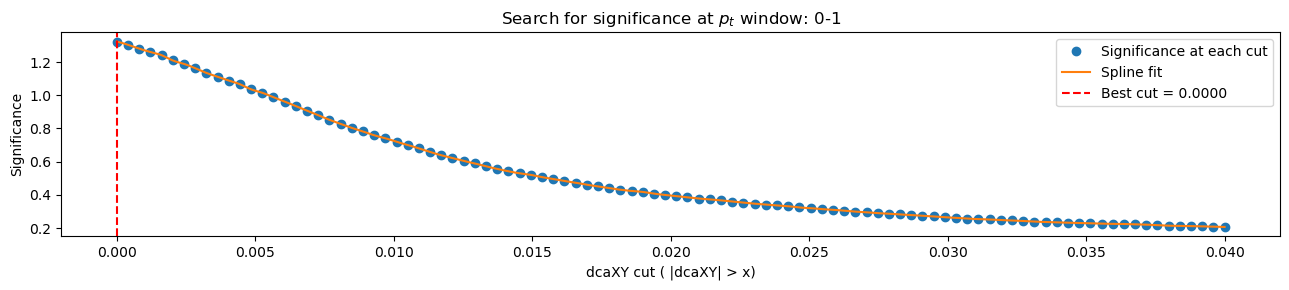

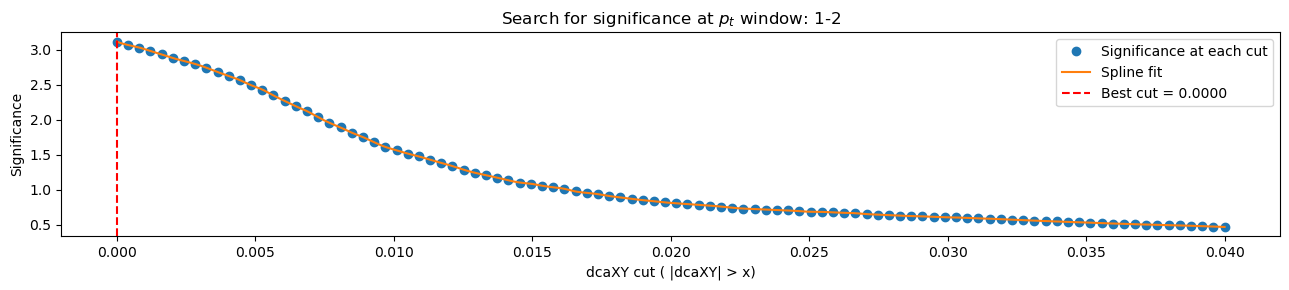

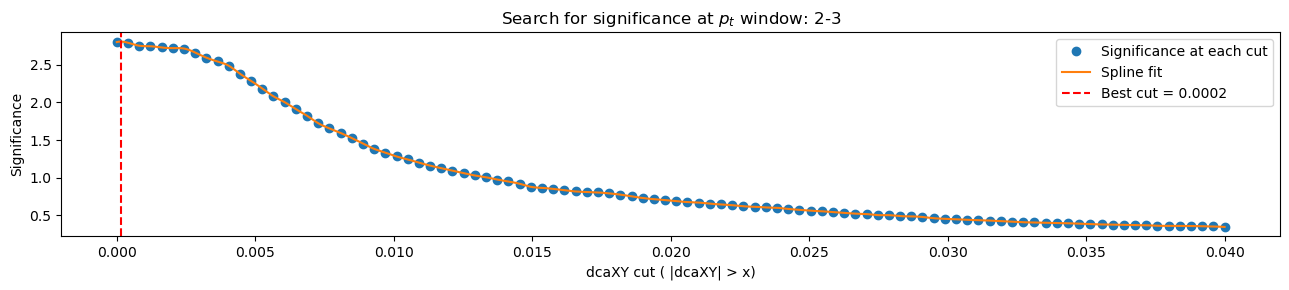

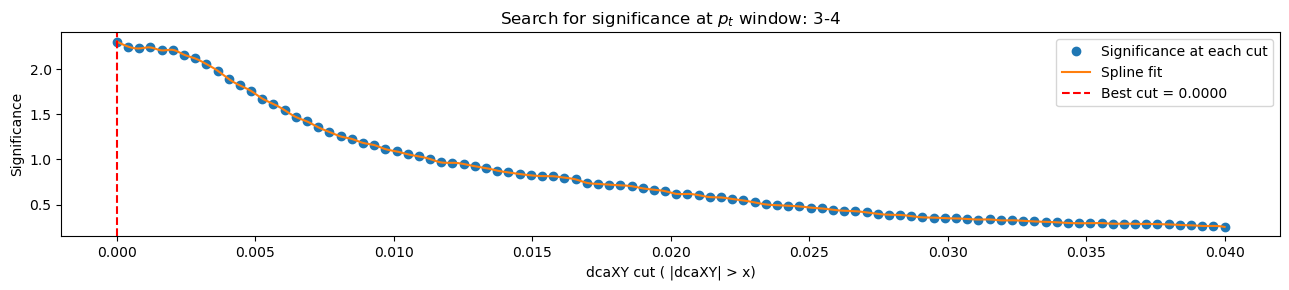

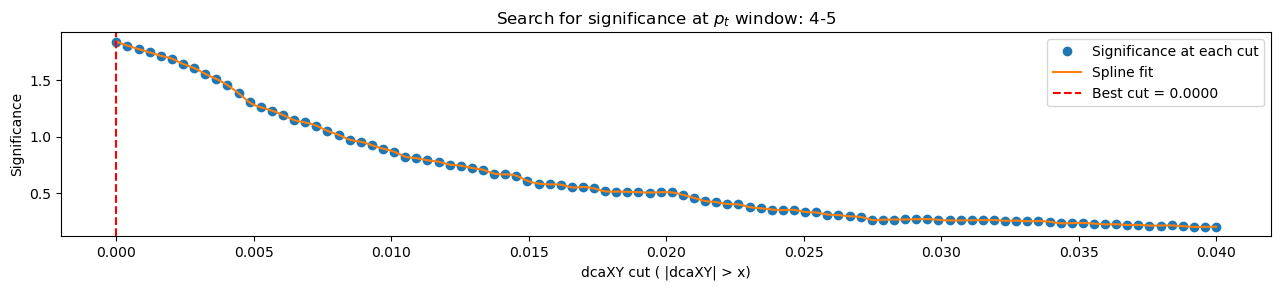

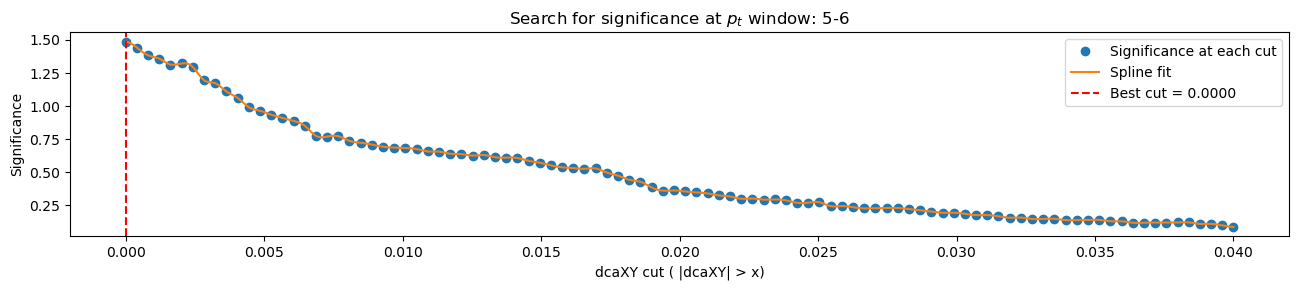

In [18]:
for i, mask_name in enumerate(pt_windows_single_track): 

    # initialization
    x_val = np.linspace( 0 , 0.04, 100)   # meaningful values for x axis
    y_val =[]       # this will save the significance value for each cut
    
    signal_df = np.concatenate([ 
                                final_results.loc[mask_signal & multiple_masks_pt_single_pos_track[i], 'pos_fDcaXY'].values,
                                final_results.loc[mask_signal & multiple_masks_pt_single_neg_track[i], 'neg_fDcaXY'].values 
                                ])
    background_df = np.concatenate([ 
                                final_results.loc[mask_background & multiple_masks_pt_single_pos_track[i], 'pos_fDcaXY'].values,
                                final_results.loc[mask_background & multiple_masks_pt_single_neg_track[i], 'neg_fDcaXY'].values 
                                ])

    # compute significance for |dcaXY| > x
    for x in x_val:
        numerator = np.sum(np.abs(signal_df) > x)
        denominator = np.sum(np.abs(background_df) > x)
        total = numerator + denominator

        y_val.append(0 if total == 0 else numerator / np.sqrt(total))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                  # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]     # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.set_title('Search for significance at $p_t$ window: ' + str(mask_name))
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('dcaXY cut ( |dcaXY| > x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()


It doesn't seem to be useful.

## SEARCH FOR BEST CUTS in TOF and TPC
Let's search (manually for now) for best cuts over the variables ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka'], appeared to be the best choices from previous plots.

Migliori cuts trovati all'ultima run (da verificare):
```
Best cuts found:
neg_TOFka: ±7.25
neg_TPCka: ±1.97
pos_TOFka: ±7.83
pos_TPCka: ±1.83
Maximum significance S/√(S+B): 5.301
```

In [19]:
# decide if searching in this run of the notebook:
search = "no"


# --- DATA ---
signal_data = final_results.loc[ 
                    mask_signal & (final_results['cos_pointing'] > 0.96) & ((final_results['pt'] > 2) & (final_results['pt'] < 8)), # rows
                    ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka']]                                                           # columns
background_data = final_results.loc[
                    mask_background  & (final_results['cos_pointing'] > 0.96) & ((final_results['pt'] > 2) & (final_results['pt'] < 8)), # rows
                    ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka']]                                                                # columns

# --- DEFINE CANDIDATE CUTS ---
neg_TOFka_cuts = np.linspace(6.8, 7.7, 7)   # example thresholds
neg_TPCka_cuts = np.linspace(1.8, 2.3, 7)
pos_TOFka_cuts = np.linspace(7.5, 8.5, 7)
pos_TPCka_cuts = np.linspace(1.5, 2.5, 7)

# --- VARIABLES ---
total_iterations = len(neg_TOFka_cuts) * len(neg_TPCka_cuts) * len(pos_TOFka_cuts) * len(pos_TPCka_cuts)
iteration = 0
best_significance = 0
best_cuts = {}


# --- GRID SEARCH ---
if search=="yes":
    for neg_TOF in neg_TOFka_cuts:
        for neg_TPC in neg_TPCka_cuts:
            for pos_TOF in pos_TOFka_cuts:
                for pos_TPC in pos_TPCka_cuts:
    
                    # debug:
                    iteration += 1
                    if iteration % 50 == 0 or iteration == 1:    # print progress every 50 iterations
                        print(f"{iteration}/{total_iterations}", end=' ')
                    
                    # define rectangular PID cut
                    signal_pass = (
                        ( (signal_data['neg_TOFka'] > -neg_TOF) & (signal_data['neg_TOFka'] < neg_TOF) &
                          (signal_data['neg_TPCka'] > -neg_TPC) & (signal_data['neg_TPCka'] < neg_TPC) )
                        |
                        ( (signal_data['pos_TOFka'] > -pos_TOF) & (signal_data['pos_TOFka'] < pos_TOF) &
                          (signal_data['pos_TPCka'] > -pos_TPC) & (signal_data['pos_TPCka'] < pos_TPC) )
                    )
                    background_pass = (
                        ( (background_data['neg_TOFka'] > -neg_TOF) & (background_data['neg_TOFka'] < neg_TOF) &
                          (background_data['neg_TPCka'] > -neg_TPC) & (background_data['neg_TPCka'] < neg_TPC) )
                        |
                        ( (background_data['pos_TOFka'] > -pos_TOF) & (background_data['pos_TOFka'] < pos_TOF) &
                          (background_data['pos_TPCka'] > -pos_TPC) & (background_data['pos_TPCka'] < pos_TPC) )
                    )
    
                    s = signal_pass.sum()
                    b = background_pass.sum()
    
                    if s + b > 0:
                        significance = s / np.sqrt(s + b)
                        if significance > best_significance:
                            best_significance = significance
                            best_cuts = {
                                'neg_TOFka': neg_TOF,
                                'neg_TPCka': neg_TPC,
                                'pos_TOFka': pos_TOF,
                                'pos_TPCka': pos_TPC
                            }

# --- RESULTS ---
if search=="yes":
    print('')
    print("Best cuts found:")
    for k, v in best_cuts.items():
        print(f"{k}: ±{v:.2f}")
    print(f"Maximum significance S/√(S+B): {best_significance:.3f}")

### APPLYING SINGLE TRACK VARIABLES CUTS

In [20]:
# single cuts:
cut_neg_TOFka = 7.3
cut_neg_TPCka = 2
cut_pos_TOFka = 7.8
cut_pos_TPCka = 1.8


# we create the cuts as a mask:
cuts = (
        ( (final_results['neg_TOFka'] > -cut_neg_TOFka) & (final_results['neg_TOFka'] < cut_neg_TOFka) &
          (final_results['neg_TPCka'] > -cut_neg_TPCka) & (final_results['neg_TPCka'] < cut_neg_TPCka) )
        |
        ( (final_results['pos_TOFka'] > -cut_pos_TOFka) & (final_results['pos_TOFka'] < cut_pos_TOFka) &
          (final_results['pos_TPCka'] > -cut_pos_TPCka) & (final_results['pos_TPCka'] < cut_pos_TPCka) )
)


In [21]:
final_results = final_results[ cuts ]

---

---

---

<center><span style="font-size:35px;"><b>PAIR VARIABLES DISTRIBUTION</b></span></center>

## DEFINING $p_t$ WINDOWS
We want now to create the masks for the various $p_t$ slices, in order to better see the signal for each $p_t$ interval: 0-1,1-2,2-3,3-5,5-8,8-16.

In [41]:
multiple_masks_pt = [ 
    final_results["pt"].between(0, 1.5), 
    final_results["pt"].between(1.5, 3),
    final_results["pt"].between(3, 8), 
    final_results["pt"].between(8, 16)
]

pt_windows = [ "0-1.5", "1.5-3", "3-8", "8-16" ]

# let's count signal and background for each pT window
signal_tot_per_pt = []
num_bg_pairs_per_pt = []

for mask_pt in multiple_masks_pt:

    # count signal for each pT window
    signal_tot = len(final_results.loc[mask_signal & mask_pt, "truth"])
    signal_tot_per_pt.append(signal_tot)

    # count background for each pT window
    bg_tot = len(final_results.loc[mask_background & mask_pt, "truth"])
    num_bg_pairs_per_pt.append(bg_tot)

## POYNTING ANGLE in $p_T$ slices

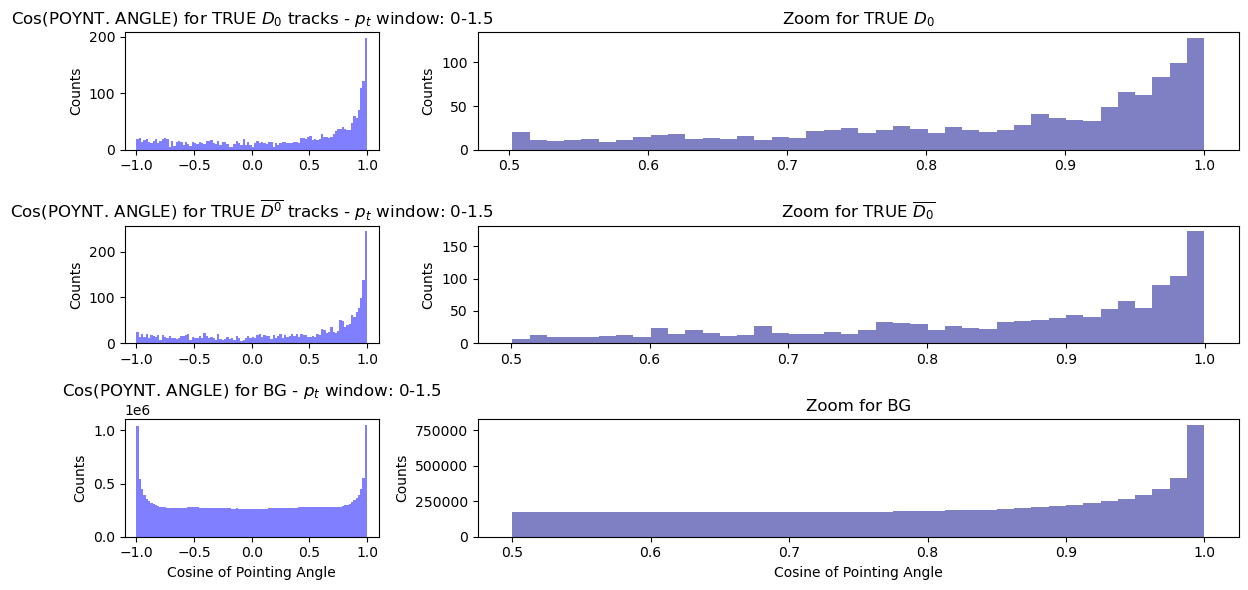

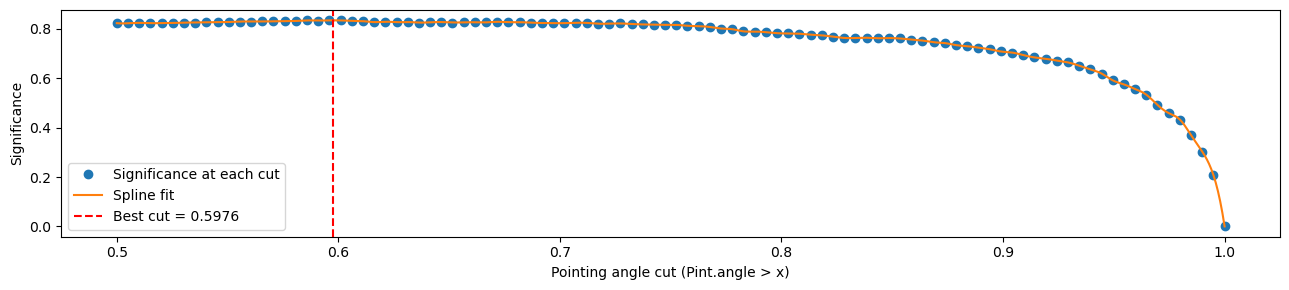

Best cut: cos(pointing) > 0.5976
With this cut we keep 50.50% of original signal
With this cut we keep 23.64% of background pairs


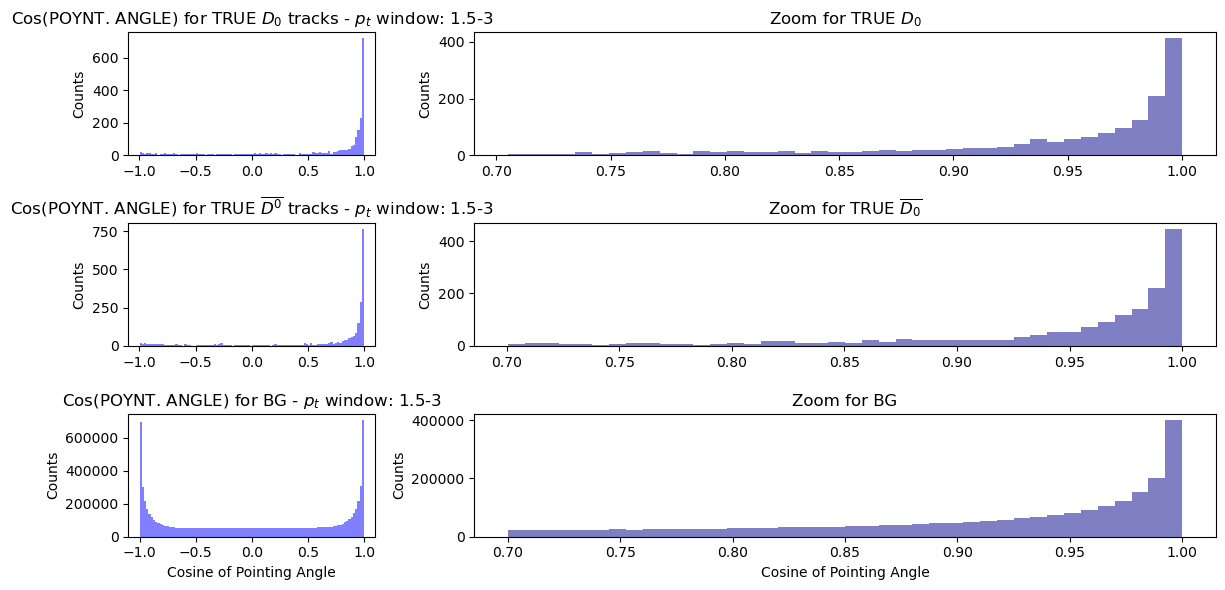

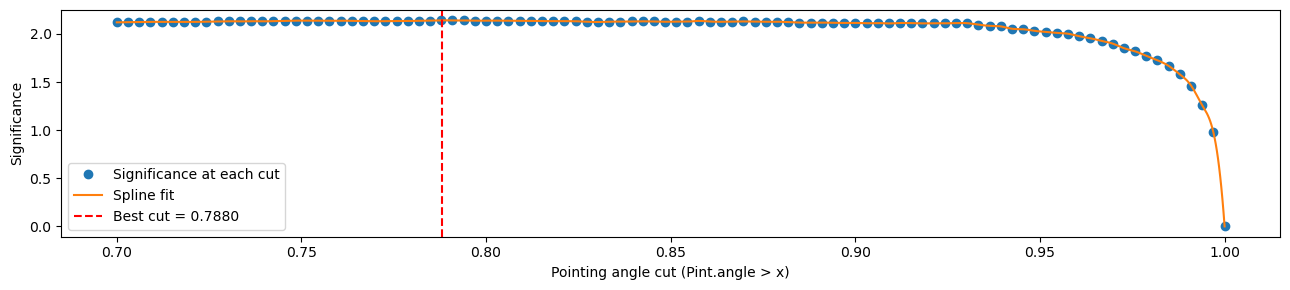

Best cut: cos(pointing) > 0.7880
With this cut we keep 65.26% of original signal
With this cut we keep 24.51% of background pairs


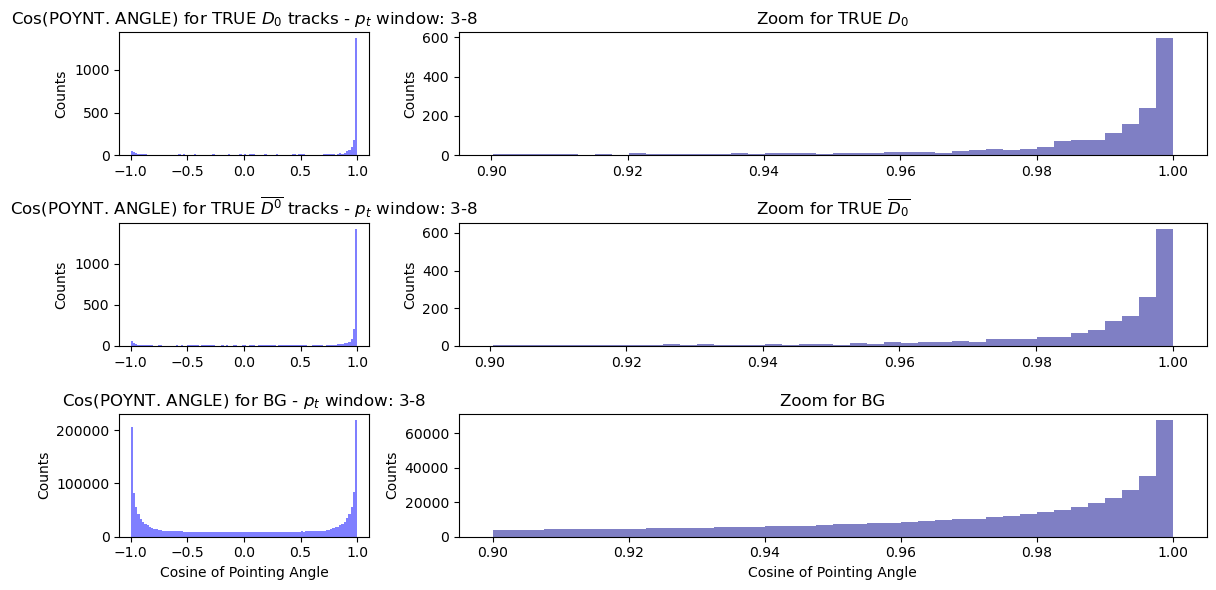

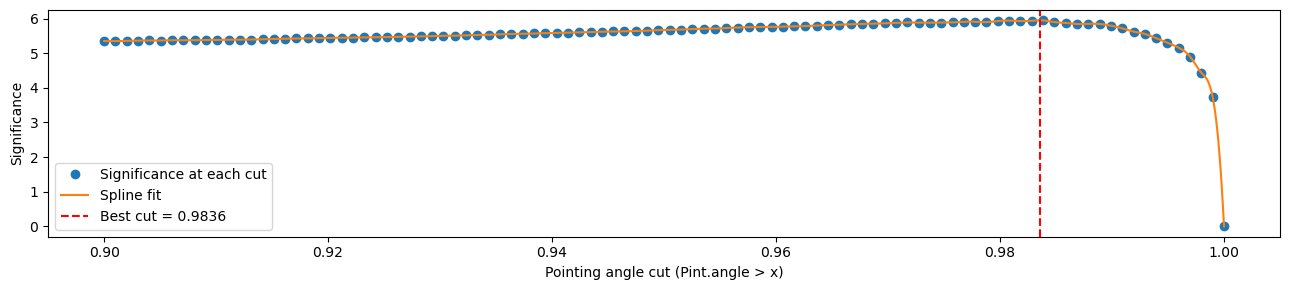

Best cut: cos(pointing) > 0.9836
With this cut we keep 50.67% of original signal
With this cut we keep 10.67% of background pairs


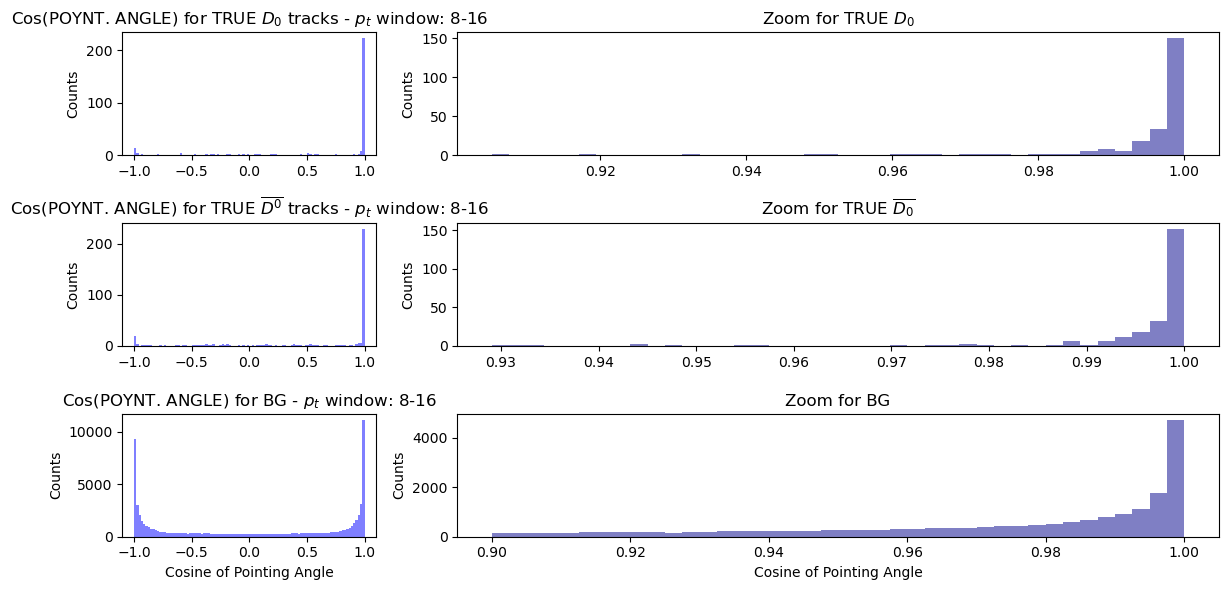

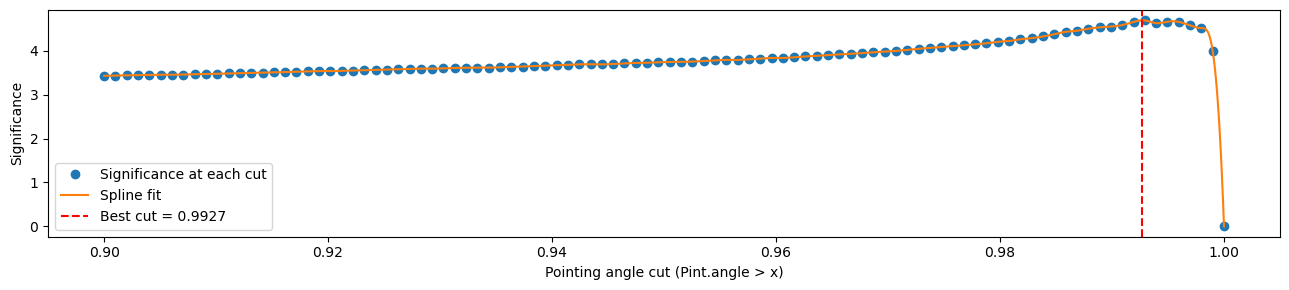

Best cut: cos(pointing) > 0.9927
With this cut we keep 58.12% of original signal
With this cut we keep 10.67% of background pairs


In [43]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )
    # meaningful cut for the zoom, depending on the pt slice we are in:
    match i:   # this command is like the usual "switch" in other languages
        case 0: cut = 0.5
        case 1: cut = 0.7
        case _: cut = 0.9
    
    # --- Plot cosine of poynting angle FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'cos_pointing'].values
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"Cos(POYNT. ANGLE) for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ data > cut ]
    axes["zoom_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot cosine of poynting angle FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'cos_pointing'].values
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"Cos(POYNT. ANGLE) for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ data > cut ]
    axes["zoom_anti_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title("Zoom for TRUE $\overline{D_0}$")
    
    # --- Plot cosine of poynting angle FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'cos_pointing'].values
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("Cosine of Pointing Angle")
    axes["total_all"].set_title(r"Cos(POYNT. ANGLE) for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ data > cut ]
    axes["zoom_all"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("Cosine of Pointing Angle")
    axes["zoom_all"].set_title("Zoom for BG")
    
    plt.tight_layout()
    plt.show()
    del data
    
    # --------------------- SEARCH FOR BEST CUT ----------------------------------------------
    # meaningful values for x axis, depending on the pt slice we are in:
    match i: 
        case 0 | 1: x_val = np.linspace(cut , 1, 100)     # case for i=0 or i=1
        case _: x_val = np.linspace( 0.9 , 1, 100)
    y_val =[]       # this will save the significance value for each cut
    
    signal_pointing = final_results.loc[ mask_pt & mask_signal, 'cos_pointing'].values
    background_pointing = final_results.loc[ mask_pt & mask_background, 'cos_pointing'].values
    
    for x in x_val:
        numerator = np.sum(signal_pointing > x)
        denominator = np.sum(background_pointing > x)
        total = numerator + denominator
        if total == 0:  y_val.append(0)   # significance is zero if no events survive
        else:           y_val.append(numerator / np.sqrt(total))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                  # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]     # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('Pointing angle cut (Pint.angle > x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # PRINT results:
    print(f"Best cut: cos(pointing) > {best_cut:.4f}")
    print(f"With this cut we keep {len( signal_pointing[ signal_pointing>best_cut ] )/signal_tot_per_pt[i]*100:.2f}% of original signal")
    print(f"With this cut we keep {len( background_pointing[ background_pointing>best_cut ] )/num_bg_pairs_per_pt[i]*100:.2f}% of background pairs")
    

## dcaXY PRODUCT in $p_T$ slices

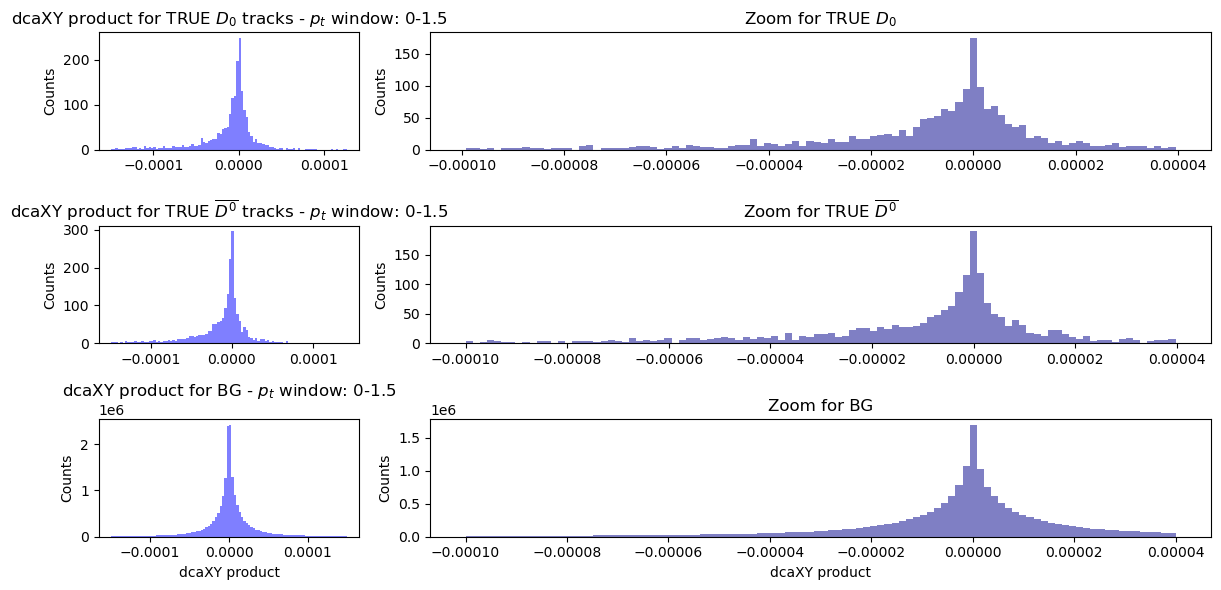

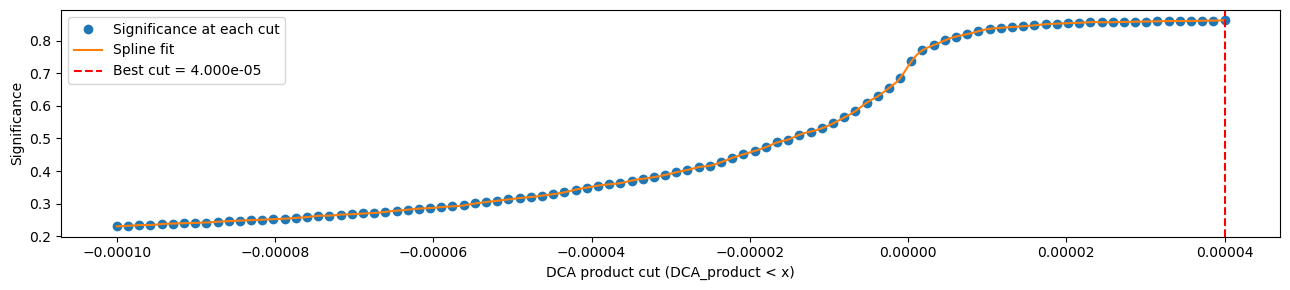

Best cut: (dcaXY product) < 4.000e-05
With this cut we keep 92.26% of original signal
With this cut we keep 73.90% of background pairs


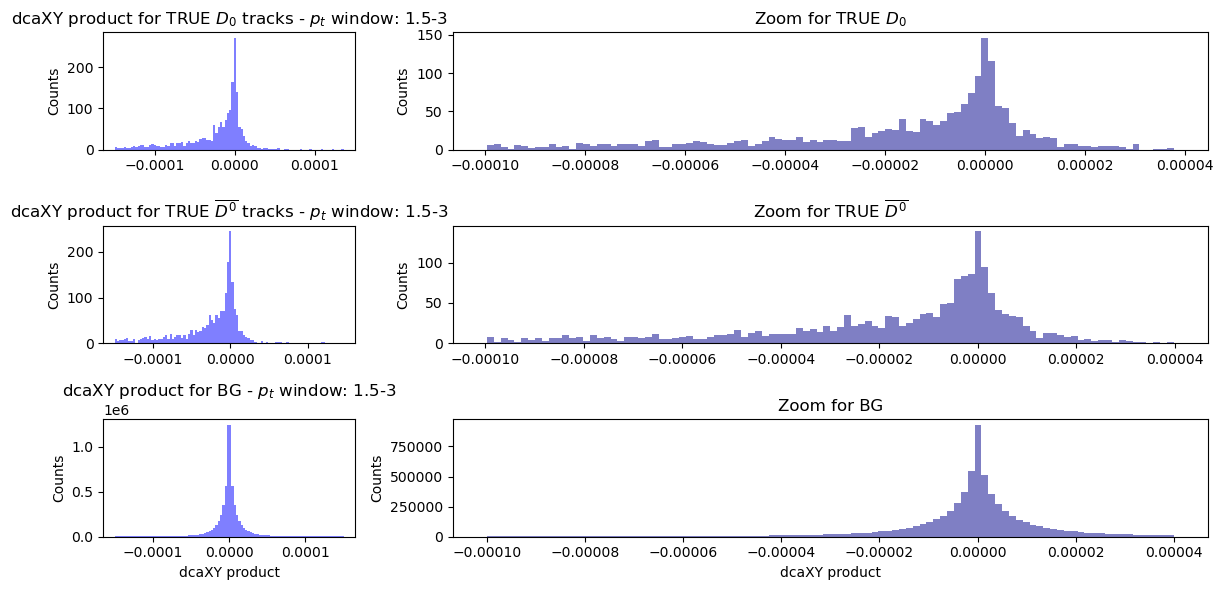

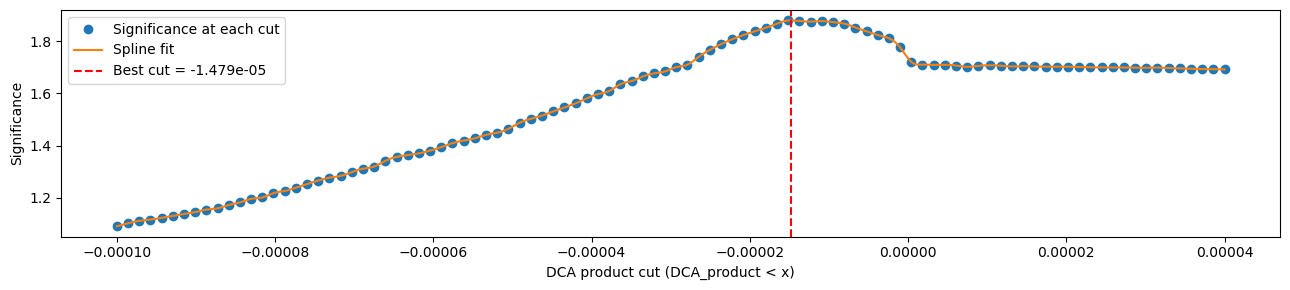

Best cut: (dcaXY product) < -1.479e-05
With this cut we keep 50.15% of original signal
With this cut we keep 18.79% of background pairs


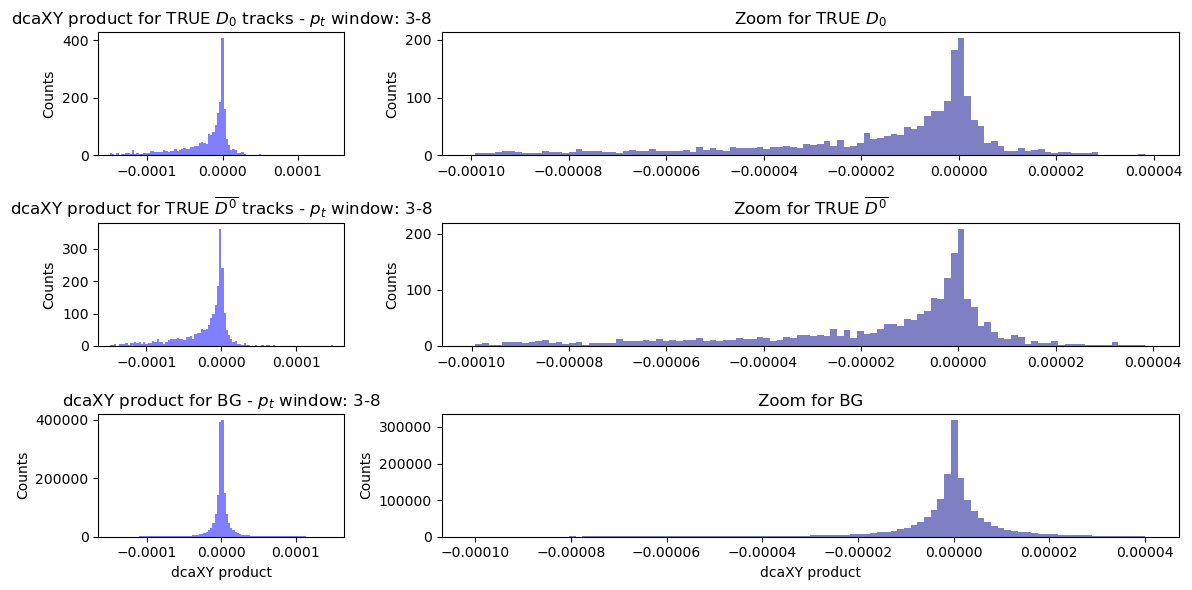

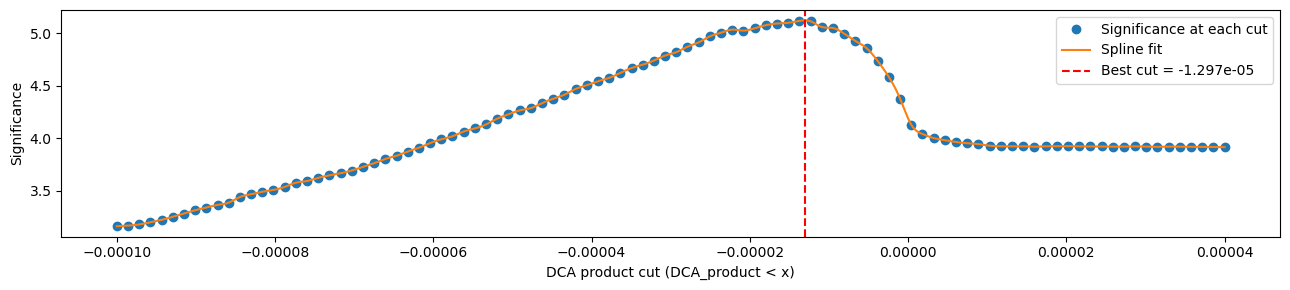

Best cut: (dcaXY product) < -1.297e-05
With this cut we keep 48.49% of original signal
With this cut we keep 13.30% of background pairs


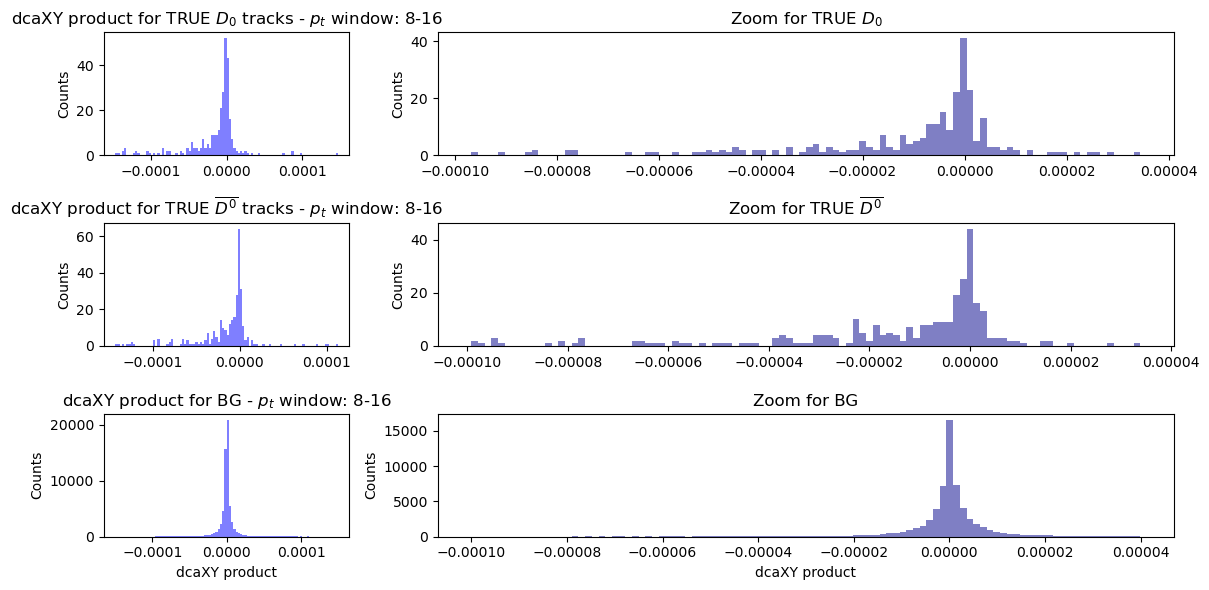

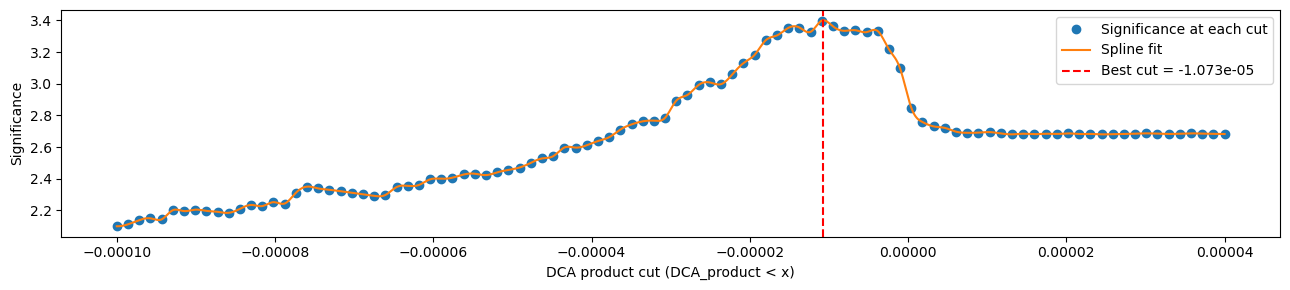

Best cut: (dcaXY product) < -1.073e-05
With this cut we keep 45.52% of original signal
With this cut we keep 12.51% of background pairs


In [46]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )
    # let's define the zoom cut:
    cut_inf = 0.0001
    cut_sup = 0.00004
    
    # --- Plot dcaXY product FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"dcaXY product for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot dcaXY product FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"dcaXY product for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))    
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_anti_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title(r"Zoom for TRUE $\overline{D^0}$")
    
    # --- Plot dcaXY product FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("dcaXY product")
    axes["total_all"].set_title(r"dcaXY product for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_all"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("dcaXY product")
    axes["zoom_all"].set_title("Zoom for BG")
    
    plt.tight_layout()
    plt.show()
    del data


    # --------------- SEARCH FOR BEST CUT IN DCA PRODUCT -------------------------------
    x_val = np.linspace( -0.0001, 0.00004, 100)
    y_val =[]                 # this will save the significance value for each cut
    
    signal_dca_prod = final_results.loc[ mask_pt & mask_signal, 'dcaXY_product'].values
    background_dca_prod = final_results.loc[ mask_pt & mask_background, 'dcaXY_product'].values
    
    for x in x_val:
        numerator = len( signal_dca_prod[ signal_dca_prod<x ] )
        denominator = len( background_dca_prod[ background_dca_prod<x ] )
        y_val.append(numerator / np.sqrt(numerator + denominator))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                 # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]    # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.3e}')
    ax.set_xlabel('DCA product cut (DCA_product < x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # PRINT results:
    print(f"Best cut: (dcaXY product) < {best_cut:.3e}")
    print(f"With this cut we keep {len( signal_dca_prod[ signal_dca_prod<best_cut ] )/signal_tot_per_pt[i]*100:.2f}% of original signal")
    print(f"With this cut we keep {len( background_dca_prod[ background_dca_prod<best_cut ] )/num_bg_pairs_per_pt[i]*100:.2f}% of background pairs")
  

## DECAY LENGTH in $p_T$ slices

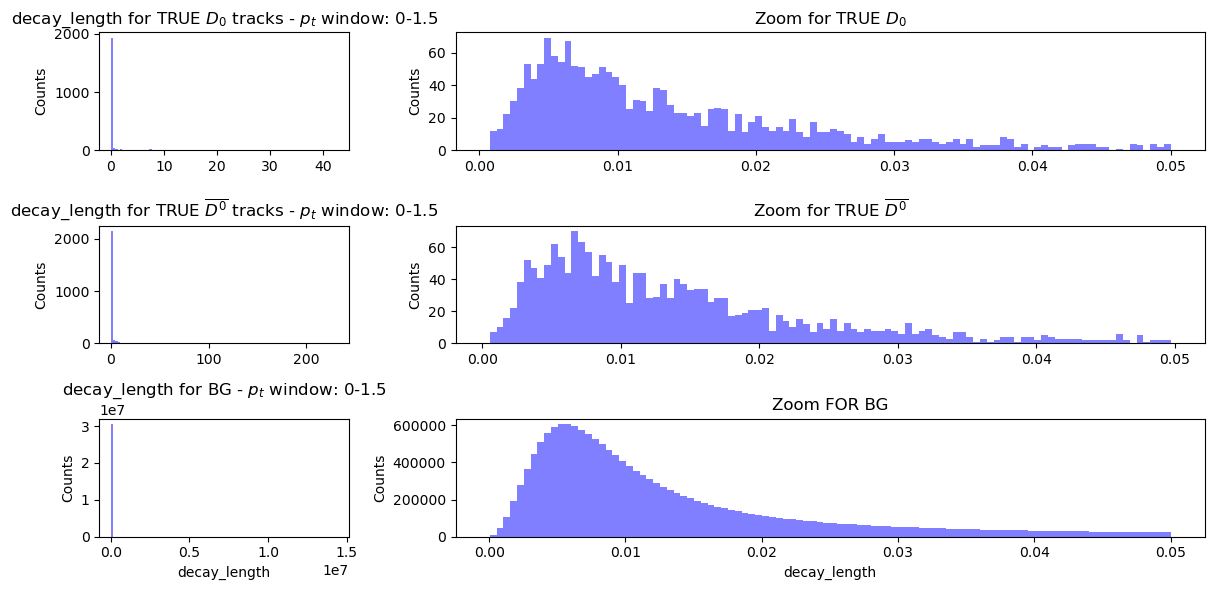

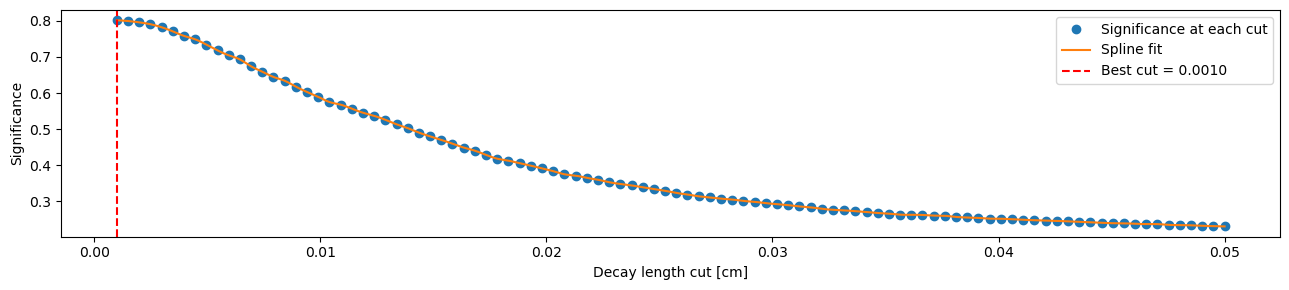

Best cut: (decay_length) > 0.0010
With this cut we keep 99.68% of the original signal
With this cut we keep 99.85% of the background pairs


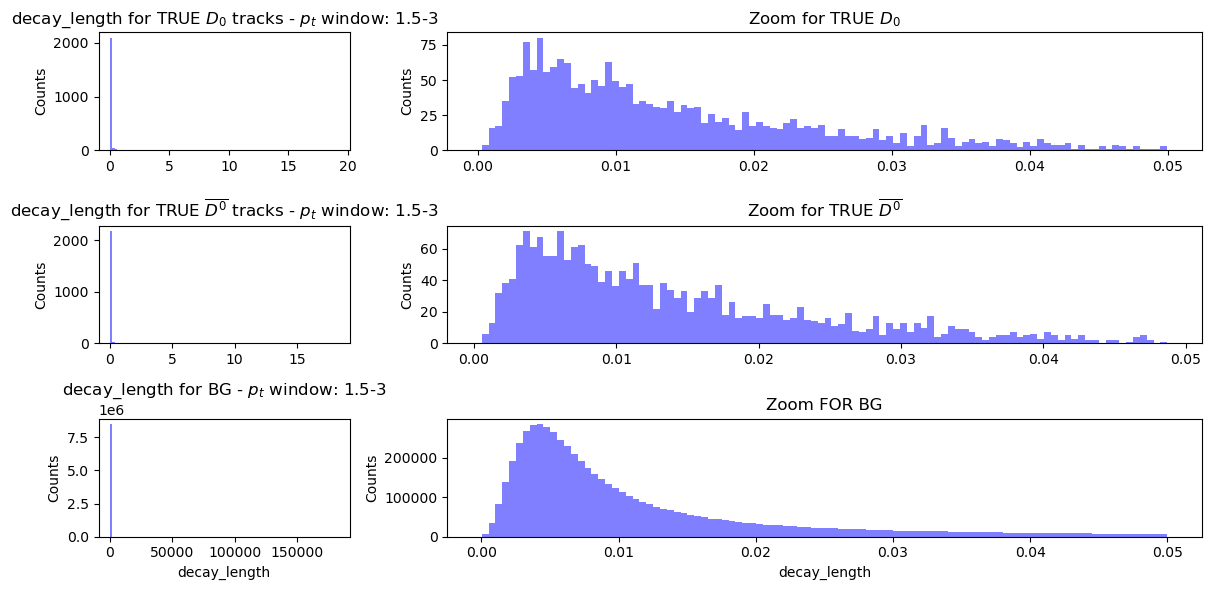

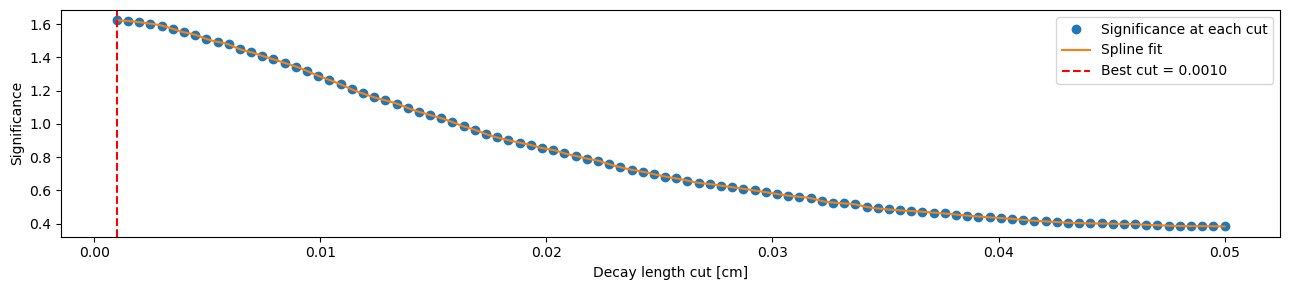

Best cut: (decay_length) > 0.0010
With this cut we keep 99.75% of the original signal
With this cut we keep 99.57% of the background pairs


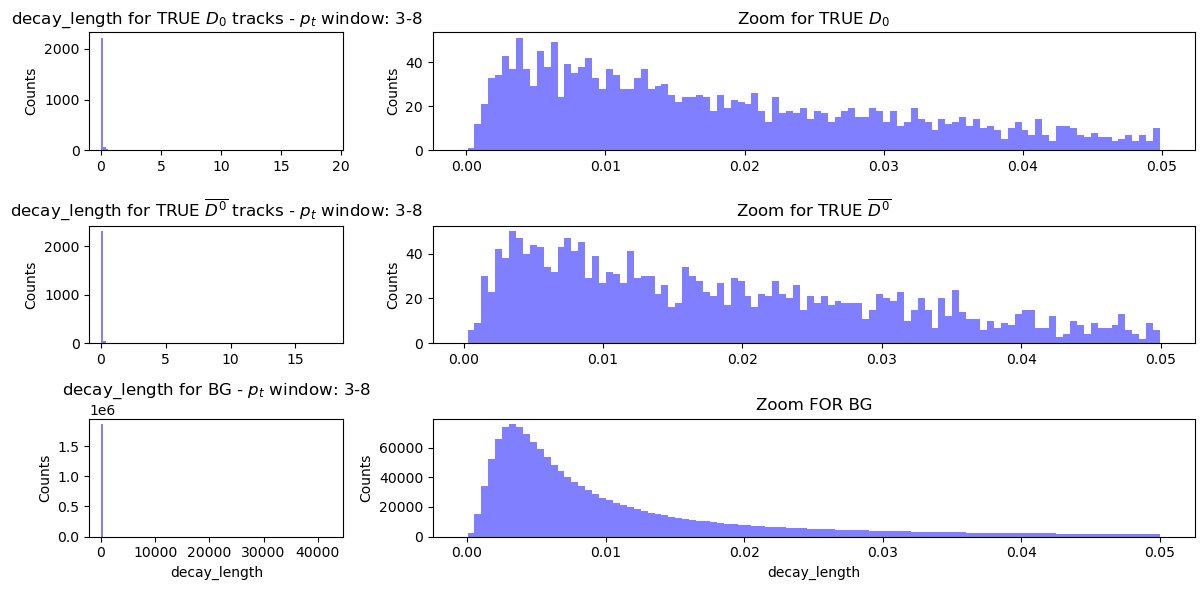

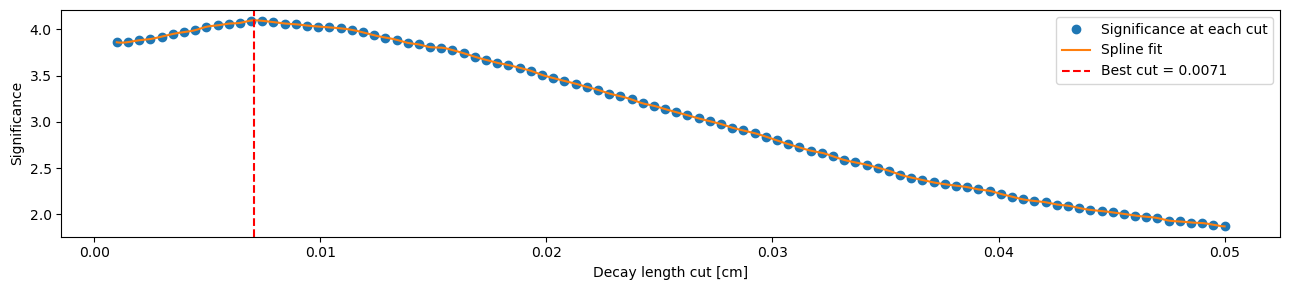

Best cut: (decay_length) > 0.0071
With this cut we keep 82.56% of the original signal
With this cut we keep 60.49% of the background pairs


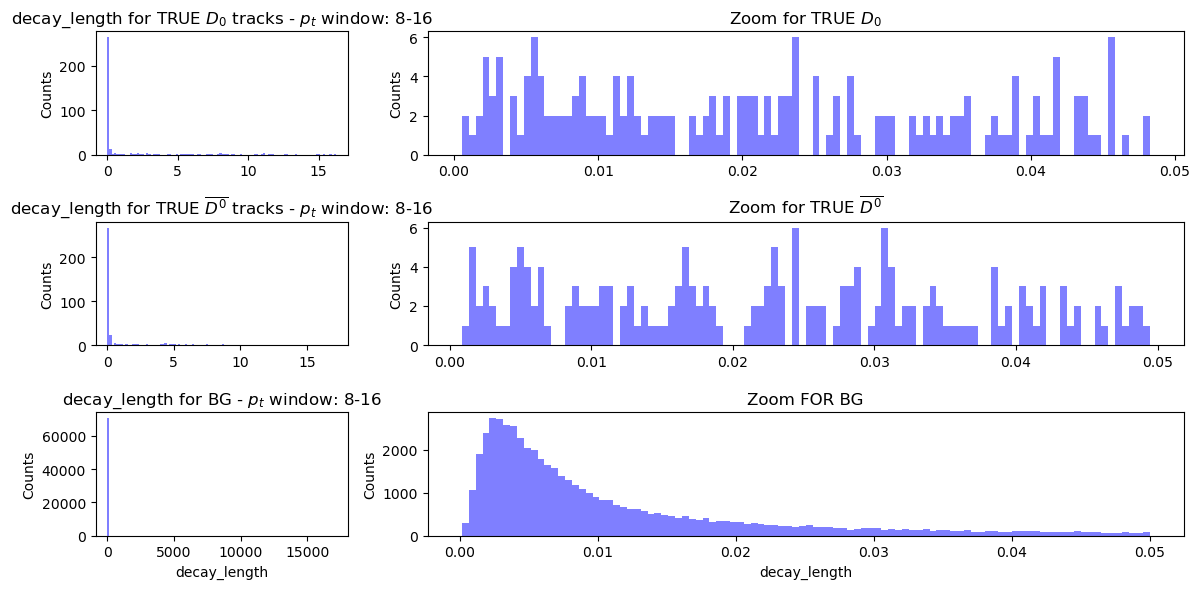

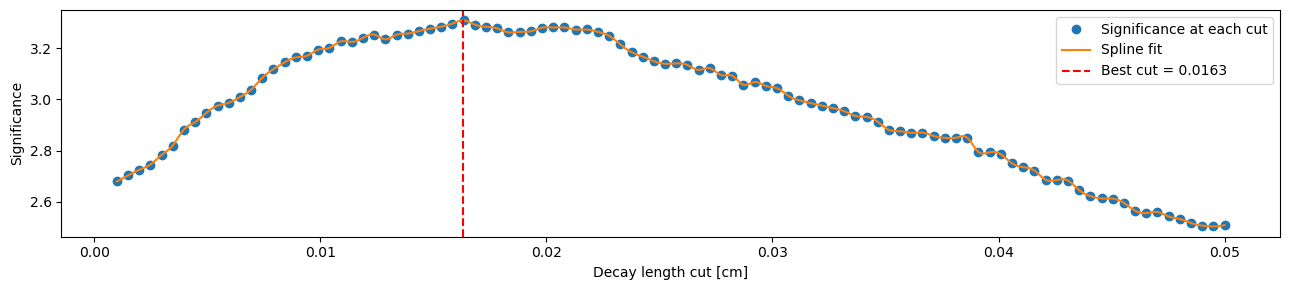

Best cut: (decay_length) > 0.0163
With this cut we keep 79.55% of the original signal
With this cut we keep 40.96% of the background pairs


In [47]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )

    # cut for the zoom part
    cut = 0.05
    
    # --- Plot decay length FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'decay_length'].values
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"decay_length for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ data < cut ]
    axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot decay length FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'decay_length'].values
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"decay_length for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ data < cut ]
    axes["zoom_anti_D0"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title(r"Zoom for TRUE $\overline{{D^0}}$")
    
    # --- Plot decay length FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'decay_length'].values
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("decay_length")
    axes["total_all"].set_title("decay_length for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ data < cut ]
    axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("decay_length")
    axes["zoom_all"].set_title("Zoom FOR BG")
    
    plt.tight_layout()
    plt.show()
    del data

    # ---------------------------- SEARCH FOR BEST CUTS FOR DECAY LENGTH ------------------------------------
    # --- RANGE OF CUTS ---
    x_val = np.linspace(0.001, 0.05, 100)
    y_val = []
    
    # --- DATA ---
    signal_dl = final_results.loc[ mask_pt & mask_signal, 'decay_length'].values
    background_dl = final_results.loc[ mask_pt & mask_background, 'decay_length'].values
    
    # --- SCAN ---
    for x in x_val:
        numerator = len( signal_dl[ signal_dl > x ] )
        denominator = len( background_dl[ background_dl > x ] )
        if numerator + denominator > 0:
            y_val.append(numerator / np.sqrt(numerator + denominator))
        else: y_val.append(0)
    
    # --- INTERPOLATION ---
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)
    best_cut = x_dense[np.argmax(y_dense)]
    
    # --- PLOT ---
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('Decay length cut [cm]')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # --- PRINT RESULTS ---
    print(f"Best cut: (decay_length) > {best_cut:.4f}")
    print(f"With this cut we keep {len(signal_dl[signal_dl > best_cut])/signal_tot_per_pt[i]*100:.2f}% of the original signal")
    print(f"With this cut we keep {len(background_dl[background_dl > best_cut])/num_bg_pairs_per_pt[i]*100:.2f}% of the background pairs")

### COMBINATION OF CUTS: POYNTING + DECAY LENGTH

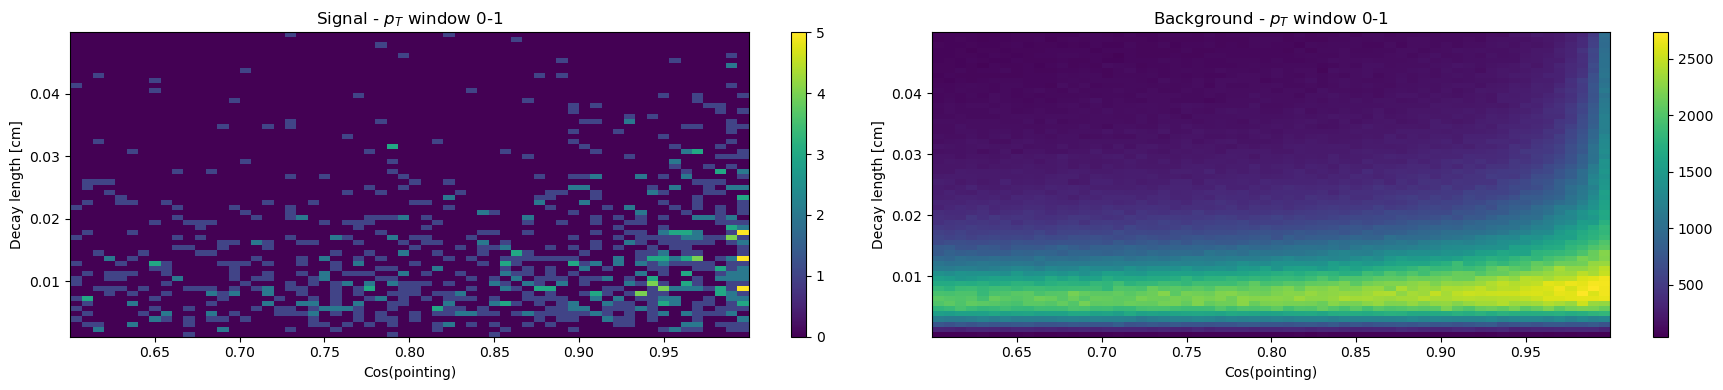

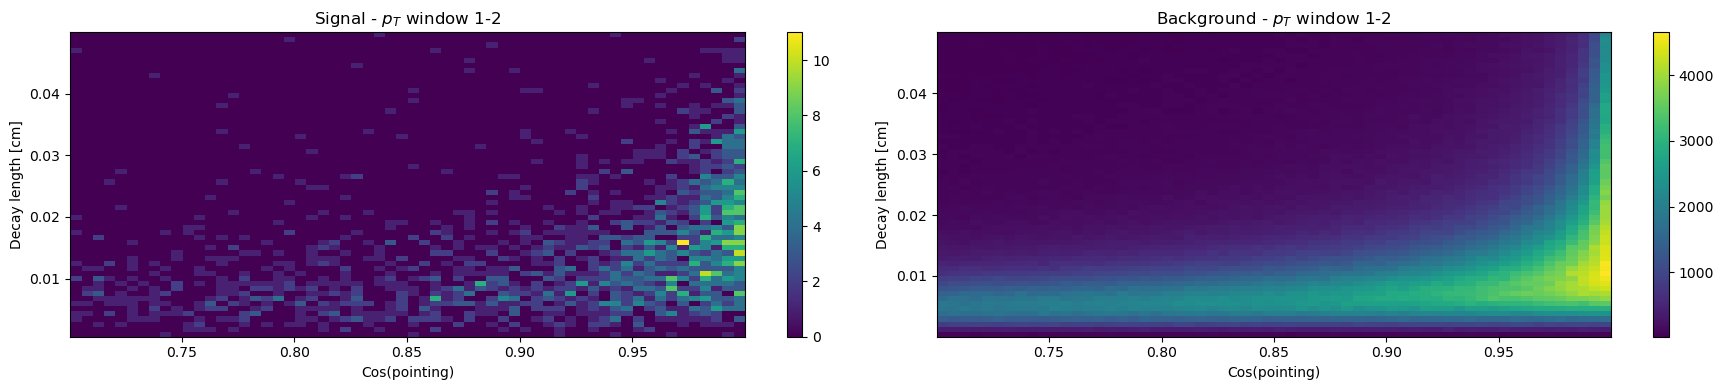

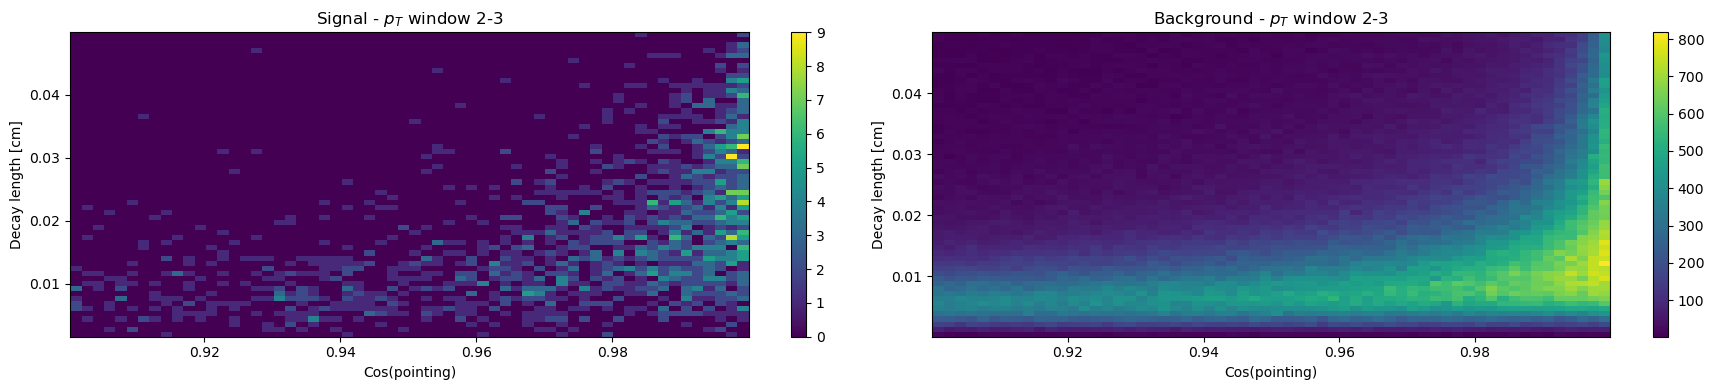

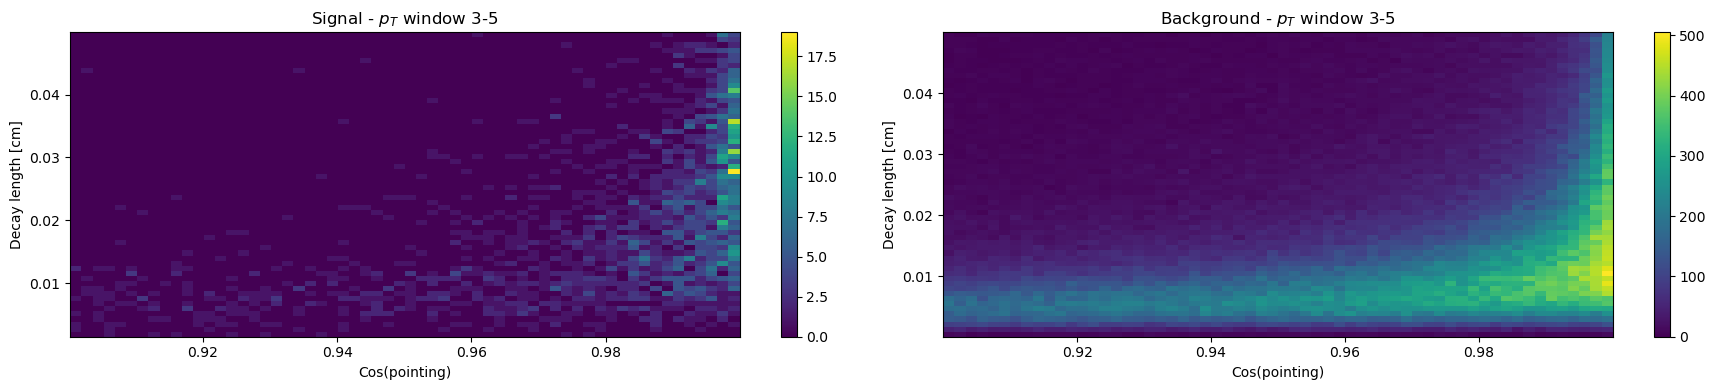

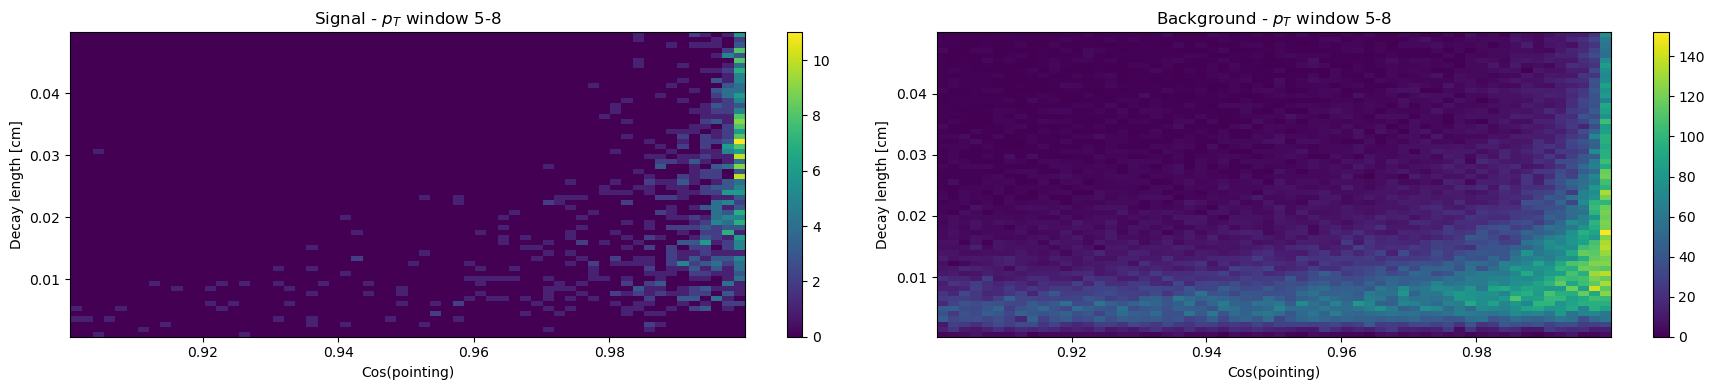

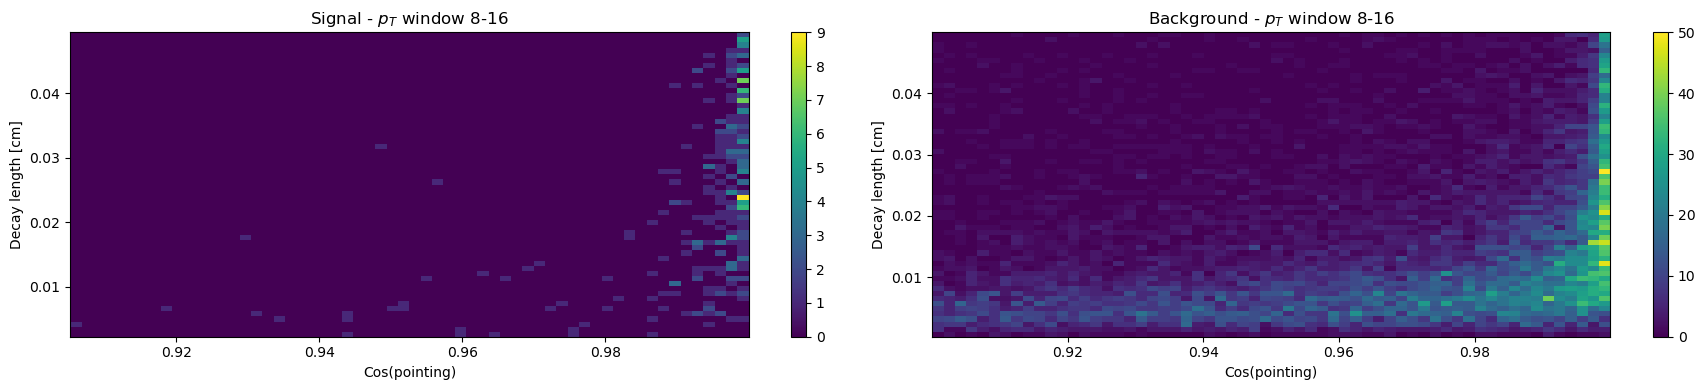

In [13]:
# choose the type of plot: "scatter", "hexbin", or "hist2d"
plot_type = "hist2d"

for i, mask_pt in enumerate(multiple_masks_pt):

    # define your two cases
    masks_cases = { "Signal" : mask_pt & mask_signal, "Background" : mask_pt & mask_background }
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    
    for ax, (label, mask) in zip(axes, masks_cases.items()):

        # CUTS TO FOCUS ON USEFUL AREAS:
        match i:   # this command is like the usual "switch" in other languages
            case 0: cut_poy = 0.6
            case 1: cut_poy = 0.7
            case _: cut_poy = 0.9
        cut_decay = 0.05
        # filter rows jointly to keep associated the two variables of a same row
        rows = final_results.loc[   mask &
                                    (final_results["cos_pointing"] > cut_poy) &
                                    (final_results["decay_length"] < cut_decay)
                                ]
        # now we extract x, y
        x = rows["cos_pointing"].values
        y = rows["decay_length"].values
        
        if plot_type == "scatter":
            ax.scatter(x, y, s=2, alpha=0.3)
        
        elif plot_type == "hexbin":
            hb = ax.hexbin(
                x, y, gridsize=50, cmap="viridis", mincnt=1
            )
            fig.colorbar(hb, ax=ax)
        
        elif plot_type == "hist2d":
            h = ax.hist2d(x, y, bins=60, cmap="viridis")
            fig.colorbar(h[3], ax=ax)
        
        ax.set_title(f"{label} - $p_T$ window {pt_windows[i]}")
        ax.set_xlabel("Cos(pointing)")
        ax.set_ylabel("Decay length [cm]")

    plt.tight_layout()
    plt.show()


### $p_T$ DISTRIBUTION

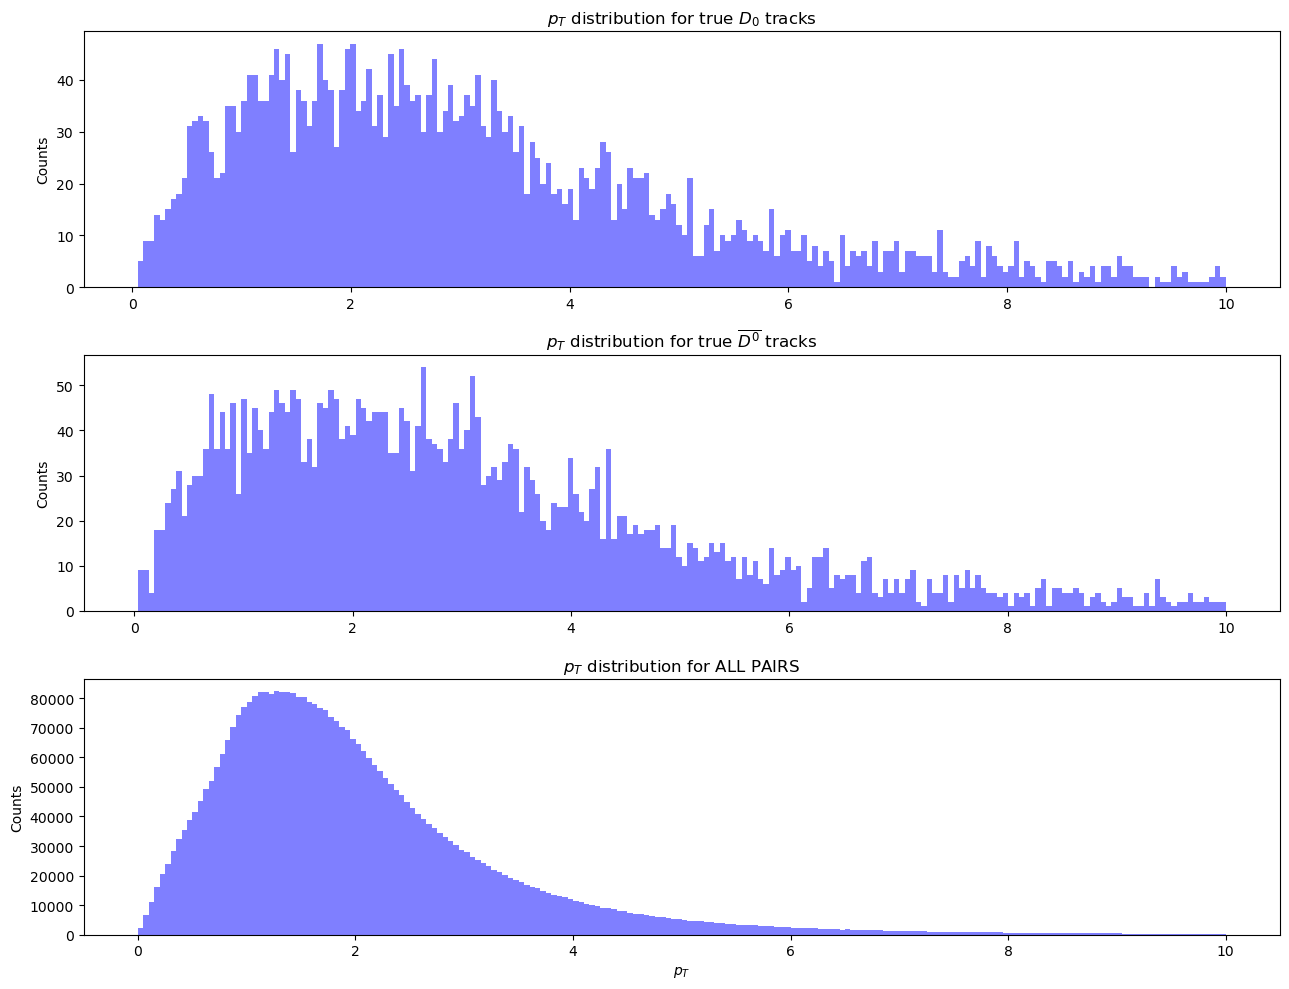

In [24]:
N_BINS = 200
fig, axs = plt.subplots(3, 1, figsize=(13, 10))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for ALL PAIRS")

plt.tight_layout()
plt.show()
del data

The $p_T$ windows like $[2-4]$, $[3-6]$ or $[3-8]$ could be useful to find the signal.

### APPLYING PAIR VARIABLES CUTS

In [18]:
# single cuts:
cut_cos_pointing = 0.96
cut_dca_product = 0.00001


# we create the cuts as a mask:
cuts = (
    (final_results['cos_pointing'] > cut_cos_pointing)
    &
    (final_results['dcaXY_product'] < cut_dca_product)
    &
    # p_t window:
    (final_results['pt'] > 2) & (final_results['pt'] < 8)
)


In [19]:
final_results = final_results[ cuts ]

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS FIT</b></span></center>

In [ ]:
# GLOBAL PLOT ---------------------------------------- 
data = np.concatenate([final_results["inv_mass"].values, final_results["anti_mass"].values])
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(0.5, 5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs[0].errorbar(bin_centers, counts, yerr=errors, fmt='-', markersize=2, color='blue')
axs[0].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No cuts)")
axs[0].legend()


# ZOOM OF GLOBAL PLOT ---------------------------------------- 
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(1.75, 2))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)
axs[1].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("Zoom of Invariant Mass (No cuts)")
axs[1].legend()

### INVARIANT MASS PLOT of data after cuts

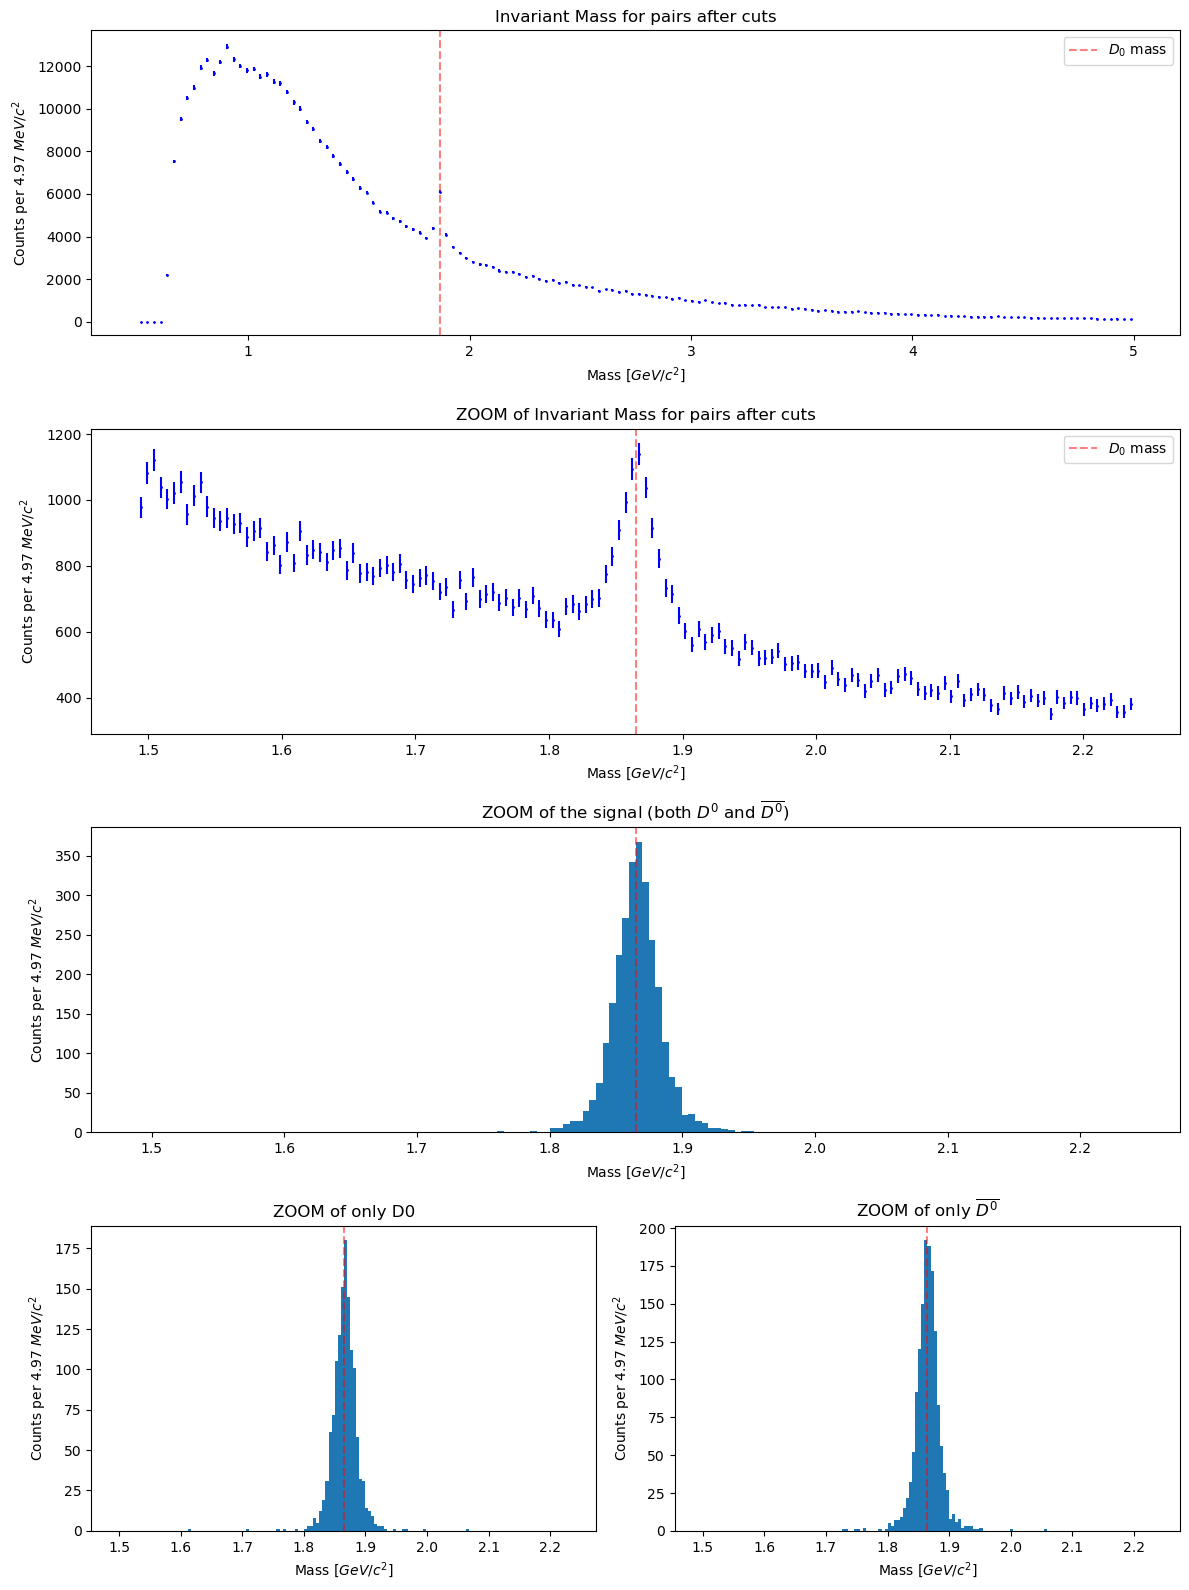

In [23]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0     # for zoom
N_BINS = 150

# Layout con due colonne
zones = [
    ["total", "total"],
    ["total_zoom", "total_zoom"],
    ["signal", "signal"],           # both D0 and anti_D0
    ["D0", "anti_D0"]
]

# Creazione della figura usando subplot_mosaic
fig, axs = plt.subplot_mosaic(
    zones,
    figsize=(12, 16),
    gridspec_kw={"width_ratios": [1, 1]}
)

# our cutted data with reflex component:---------------------------------
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate( [data_inv_mass, data_anti_mass] )

# PLOT OF ALL PAIRS
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(0.5, 5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs["total"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs["total"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs["total"].set_xlabel("Mass [$GeV/c^2$]")
axs["total"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["total"].set_title("Invariant Mass for pairs after cuts")
axs["total"].legend()

# ZOOM OF ALL PAIRS
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs["total_zoom"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs["total_zoom"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs["total_zoom"].set_xlabel("Mass [$GeV/c^2$]")
axs["total_zoom"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["total_zoom"].set_title("ZOOM of Invariant Mass for pairs after cuts")
axs["total_zoom"].legend()

# out cutted and true D0 -------------------------------------------------
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )

# ZOOM OF the signal:
axs["signal"].hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["signal"].set_xlabel("Mass [$GeV/c^2$]")
axs["signal"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["signal"].set_title("ZOOM of the signal (both $D^0$ and $\overline{{D^0}}$)")

# ZOOM OF only D0
axs["D0"].hist( data_inv_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["D0"].set_title("ZOOM of only D0")

# ZOOM OF only anti_D0
axs["anti_D0"].hist( data_anti_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["anti_D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["anti_D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["anti_D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["anti_D0"].set_title("ZOOM of only $\overline{{D^0}}$")

#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

#### INFO ON THE CUTS

In [24]:
data_inv_bg  = final_results.loc[ mask_background & cuts, 'inv_mass'].values
data_anti_bg = final_results.loc[ mask_background & cuts, 'anti_mass'].values
data_bg = np.concatenate( [data_inv_bg, data_anti_bg] )

print(f"Total D0 before cuts:               {d0_tot}")
print(f"Total D0 found after cuts:          {len(data_inv_mass_true)} ---> {len(data_inv_mass_true)/d0_tot*100:.2f}% \n")
print(f"Total anti-D0 before cuts:          {anti_d0_tot}")
print(f"Total anti-D0 found after cuts:     {len(data_anti_mass_true)} ---> {len(data_anti_mass_true)/anti_d0_tot*100:.2f}% \n")
print(f"Total signal before cuts:           {signal_tot}")
print(f"Total signal found after cuts:      {len(data_inv_mass_true)+len(data_anti_mass_true)} ---> {(len(data_inv_mass_true)+len(data_anti_mass_true))/signal_tot*100:.2f}% \n")

print(f"Total background found after cuts:       ---> {len(data_bg)/num_bg_pairs*100:.2f}% \n")

# LET'S COUNT THE D0 INSIDE AN INTERVAL:
print(f"LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL): \n")
sigma_guess = 0.015
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
signal_filtered = signal[ (signal > m_d0 - 3*sigma_guess) & (signal < m_d0 + 3*sigma_guess) ]
# background:
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
bg = np.concatenate( [data_inv_mass, data_anti_mass] )
bg_filtered = bg[ (bg > m_d0 - 3*sigma_guess) & (bg < m_d0 + 3*sigma_guess) ]
print(f"Signal found in the interval:     {len(signal_filtered)}")
print(f"Background found in the interval: {len(bg_filtered)}\n")
print(f"Percentage of signal inside the interval: {len(signal_filtered)/ (len(bg_filtered) + len(signal_filtered) )*100:.2f}%")
print(f"Significance:                     {len(signal_filtered)/np.sqrt( len(bg_filtered)+ len(signal_filtered)):.2f}")
print(f"Ratio (signal/bg):                {len(signal_filtered)/len(bg_filtered):.2f}")

Total D0 before cuts:               8815
Total D0 found after cuts:          1307 ---> 14.83% 

Total anti-D0 before cuts:          9289
Total anti-D0 found after cuts:     1460 ---> 15.72% 

Total signal before cuts:           18104
Total signal found after cuts:      2767 ---> 15.28% 

Total background found after cuts:       ---> 0.96% 

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL): 

Signal found in the interval:     2661
Background found in the interval: 14579

Percentage of signal inside the interval: 15.44%
Significance:                     20.27
Ratio (signal/bg):                0.18


---

# FITTING MASS

We try to fit the invariant mass histogram using:
* a gaussian for the signal
* a gaussian for the reflex component
* a linear function for the background

We do it in a way so that the ratio $N_1/N_2$ between the two gaussian is fixed, and the parameter $k$ is free:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Reflex} + \text{Signal} \right) + \text{Background}
$$

which means:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Gaussian1} + \text{Gaussian2} \right) + a \cdot x +b
$$

#### FINDING RATIO $N_1/N_2$
Let's fit the data given by signal + reflex component (using MC info).

Ratio (reflex/sign): 0.7970491684788387


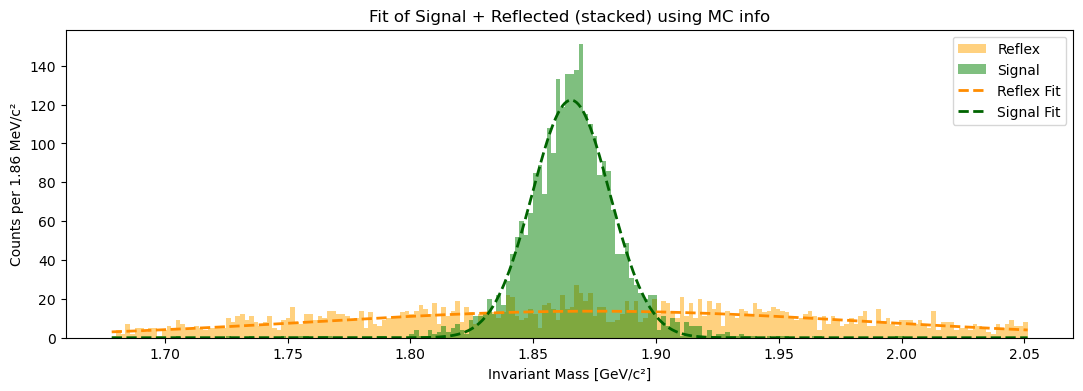

In [25]:
# --- Fit function: double Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# Histogram of signal and rflected part data only
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & cuts, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & cuts, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
# Stacked histogram
fig, ax = plt.subplots(figsize=(13,4))

# HISTOGRAM:
# ------- reflex component:
reflex_counts, reflex_edges, _ = ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
# poisson errors:
sigma_reflex_hist = np.sqrt(reflex_counts)
sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
sign_params = sign_fit_res[0]
mu_sign, sigma_sign = sign_params[1], sign_params[2]
k_sign = sign_params[0]
# ----
reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
reflex_params = reflex_fit_res[0]
mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
k_reflex = reflex_params[0]

# PRINT:
ratio_from_fit = k_reflex/k_sign
print(f"Ratio (reflex/sign): {ratio_from_fit}")

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Fit of Signal + Reflected (stacked) using MC info")
ax.legend()
plt.show()

#### INVARIANT MASS FIT

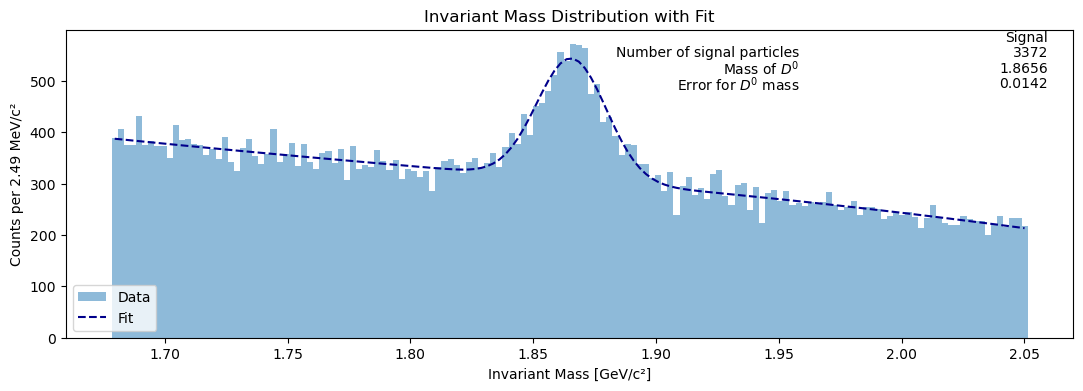

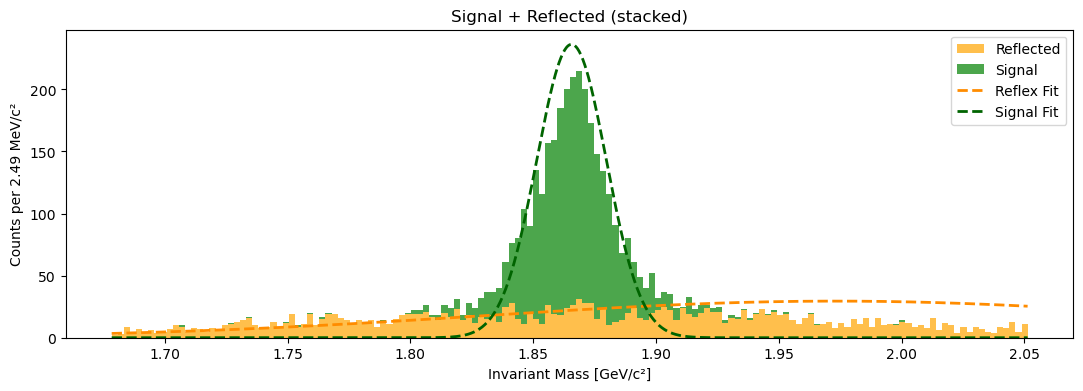

Results of signal fit: D0 mass  1.865605        error 0.014156
Results of reflex fit: center   1.973412        error 0.142301
Ratio N1/N2: 0.945371


In [26]:
# --- Fit function: double Gaussian + linear background ---
ratio =  ratio_from_fit   # fixed ratio between Gaussians
def fit_function(x, k, mu1, sigma1, mu2, sigma2, a, b):
    return k * (ratio*norm.pdf(x, loc=mu1, scale=sigma1) + norm.pdf(x, loc=mu2, scale=sigma2)) + a*x + b

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 150
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
signal_params = [m_d0, 0.02]
mirror_params = [m_d0, 0.1]
back_params   = [133, 1000]
# --- Data ---
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate([data_inv_mass, data_anti_mass])

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
both_counts, both_edges, _ = ax.hist(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Data')
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)  # avoid zeros

# FIT:
both_fit_res = curve_fit( f = fit_function, xdata = both_centers, ydata = both_counts, sigma = sigma_hist,
                            p0 = [k_param, 
                                  signal_params[0], signal_params[1],
                                  mirror_params[0], mirror_params[1],
                                  back_params[0], back_params[1]
                                 ]
                        )
both_params = both_fit_res[0]
mu1, sigma1 = both_params[1], both_params[2]
mu2, sigma2 = both_params[3], both_params[4]
k_fit = both_params[0]

# PLOT of fitted curve:
ax.plot(
    both_centers,
    fit_function( both_centers, both_params[0], both_params[1], both_params[2],
        both_params[3], both_params[4], both_params[5], both_params[6]
    ),
    color='darkblue', linestyle='dashed', linewidth=1.5, label='Fit'
)

# COUNT of D0:
mass_from_fit = both_params[1]
sigma_from_fit = both_params[2]
counts_from_fit = both_params[0] * ratio * (norm.cdf(MAX_MASS, loc=mu1, scale=sigma1) - norm.cdf(MIN_MASS, loc=mu1, scale=sigma1)) /binsize

# TABLE INSIDE PLOT:
ax.table(
    cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
    rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
    colLabels = ['Signal'],
    colLoc = "right",
    bbox = [0.75, 0.8, 0.25, 0.2],
    edges = 'open',
    rowLoc = 'right'
)

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Invariant Mass Distribution with Fit")
ax.legend(loc='lower left') 
plt.show()

# -------------------------------------------------------------------------------------------------------------

# SECOND PLOT: signal and reflected plot with two Gaussians
fig, ax = plt.subplots(figsize=(13,4))

# Histogram of signal and rflected part data only
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & cuts, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & cuts, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
# Stacked histogram
ax.hist([reflex_data, signal_data], bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        stacked=True, color=['orange', 'green'], alpha=0.7,
        label=['Reflected', 'Signal'])

# Fitted Gaussians
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, k_fit*norm.pdf(x_fit, loc=mu2, scale=sigma2), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, k_fit*ratio*norm.pdf(x_fit, loc=mu1, scale=sigma1), '--', color='darkgreen', linewidth=2, label='Signal Fit')

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Signal + Reflected (stacked)")
ax.legend()
plt.show()

print(f"Results of signal fit: D0 mass  {mass_from_fit:3f}        error {sigma_from_fit:3f}")
print(f"Results of reflex fit: center   {mu2:3f}        error {sigma2:3f}")
print(f"Ratio N1/N2: {mu1/mu2:3f}")

In [27]:
print(f"True number of signal particles:     {len(signal_filtered)}")
print(f"Expected number of signal particles: {counts_from_fit:.0f}")

True number of signal particles:     2661
Expected number of signal particles: 3372


It appears that the reflex component is too large and very plain, in a way that the fit isn't able to distinguish it from the background.